# Exploratory Data Analysis of Heart Disease Dataset

### Understanding Patient Characteristics, Clinical Features, and Their Relationship with Heart Disease


## Project Objective

The objective of this project is to explore the Heart Disease dataset, understand its structure and data quality, analyze the distribution of clinical and demographic features, and investigate patterns associated with the presence of heart disease.
The analysis focuses on:


- Understanding the characteristics of the dataset and its features
- Identifying missing values, duplicate records, and potential outliers
- Exploring demographic characteristics such as age and sex
- Examining clinical features such as chest pain, thalium stress test results, cholesterol, resting blood pressure, and maximum heart rate
- Investigating relationships between selected numerical and categorical features and heart disease status
- Summarizing the main patterns and observations identified during the analysis

## Dataset Overview


The dataset contains clinical and demographic information for 303 patients. It includes 14 attributes describing patient characteristics, clinical measurements, diagnostic test results, and heart disease status.

The `target` variable indicates whether heart disease is present:

* `0` = No disease
* `1` = Presence of disease

### Feature Description

| Feature    | Description                                                                                               |
| ---------- | --------------------------------------------------------------------------------------------------------- |
| `age`      | Age of the patient in years                                                                               |
| `sex`      | Sex of the patient (`0` = male, `1` = female)                                                             |
| `cp`       | Chest pain type (`0` = typical angina, `1` = atypical angina, `2` = non-anginal pain, `3` = asymptomatic) |
| `trestbps` | Resting blood pressure in mm Hg                                                                           |
| `chol`     | Serum cholesterol in mg/dl                                                                                |
| `fbs`      | Fasting blood sugar above 120 mg/dl (`1` = true, `0` = false)                                             |
| `restecg`  | Resting electrocardiographic results                                                                      |
| `thalach`  | Maximum heart rate achieved during a stress test                                                          |
| `exang`    | Exercise-induced angina (`1` = yes, `0` = no)                                                             |
| `oldpeak`  | ST depression induced by exercise relative to rest                                                        |
| `slope`    | Slope of the peak exercise ST segment                                                                     |
| `ca`       | Number of major vessels colored by fluoroscopy (`0`–`4`)                                                  |
| `thal`     | Thalium stress test result                                                                                |
| `target`   | Heart disease status (`0` = no disease, `1` = presence of disease)                                        |

Categorical feature codes are retained according to the dataset documentation and are interpreted using their corresponding feature descriptions during the analysis.


## Tools & Libraries

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn

## Workflow

1. Import libraries
2. Load and inspect the dataset
3. Understand the dataset structure and features
4. Assess data quality
5. Handle duplicate records
6. Explore numerical and categorical variables
7. Investigate relationships with heart disease status
8. Identify potential outliers
9. Analyze correlations between numerical features
10. Summarize key findings


## Data Loading & Initial Inspection

In [1]:
#import_libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load_dataset

Data = pd.read_csv("../data/heart.csv")

#DataFrame

df = pd.DataFrame(Data)

### Dataset Information

In [3]:
Data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [4]:
#number_of_rows&columns

rows, columns =df.shape
print(f"Number of Rows are : {rows}",'\n',f"Number of columns are : {columns}")

Number of Rows are : 303 
 Number of columns are : 14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
#Describe_Dataset

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
#Column_Details

def col_detail (df):
    col_name = []
    dtypes = []
    count = []
    unique = []
    for col in df.columns:
        col_name.append(col)
        dtypes.append(df[col].dtype)
        count.append(len(df[col]))
        unique.append(len(df[col].unique()))
        
    output = pd.DataFrame({
        'Column_name' : col_name,
        'Dtype' : dtypes,
        'Count' : count,
        'Unique': unique
    })
    return output

col_detail(df)

,Column_name,Dtype,Count,Unique
0,age,int64,303,41
1,sex,int64,303,2
2,cp,int64,303,4
3,trestbps,int64,303,49
4,chol,int64,303,152
5,fbs,int64,303,2
6,restecg,int64,303,3
7,thalach,int64,303,91
8,exang,int64,303,2
9,oldpeak,float64,303,40


## Data Quality Assessment

### Missing Values

In [8]:
#missing_values_each_col

print("Number of missing values in each column :" , "\n ")
print(df.isna().sum())

#number_of_missing_values
num_of_missing_value= df.isna().sum().sum()

print(f"number of missing values : {num_of_missing_value}")

Number of missing values in each column : 
 
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
number of missing values : 0


There are no missing values in this dataset.

### Unique Values

In [9]:

for column in df.columns:
    print(f"Unique Values in '{column}':")
    print(df[column].unique())
    print("_"*40)

Unique Values in 'age':
[63 37 41 56 57 44 52 54 48 49 64 58 50 66 43 69 59 42 61 40 71 51 65 53
 46 45 39 47 62 34 35 29 55 60 67 68 74 76 70 38 77]
________________________________________
Unique Values in 'sex':
[1 0]
________________________________________
Unique Values in 'cp':
[3 2 1 0]
________________________________________
Unique Values in 'trestbps':
[145 130 120 140 172 150 110 135 160 105 125 142 155 104 138 128 108 134
 122 115 118 100 124  94 112 102 152 101 132 148 178 129 180 136 126 106
 156 170 146 117 200 165 174 192 144 123 154 114 164]
________________________________________
Unique Values in 'chol':
[233 250 204 236 354 192 294 263 199 168 239 275 266 211 283 219 340 226
 247 234 243 302 212 175 417 197 198 177 273 213 304 232 269 360 308 245
 208 264 321 325 235 257 216 256 231 141 252 201 222 260 182 303 265 309
 186 203 183 220 209 258 227 261 221 205 240 318 298 564 277 214 248 255
 207 223 288 160 394 315 246 244 270 195 196 254 126 313 262 215 193 271
 268

The unique values of the dataset were reviewed to identify unexpected or inconsistent categorical values.

 No obvious invalid category labels were observed during this check.


The continuous variables considered in this analysis are age, trestbps, chol, thalach, and oldpeak.

### Duplicate Records

In [10]:
#Number_of_Duplicate_Records

df.duplicated().sum()

1

In [11]:
#Duplicate_Record

df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [12]:
#Remove_Duplicate

df.drop_duplicates(inplace=True)

Duplicate records were identified and removed before continuing with the exploratory analysis. The analysis therefore uses the deduplicated dataset.

In [13]:
df.shape

(302, 14)

### Distribution / potential outliers

#### Histogram Plot

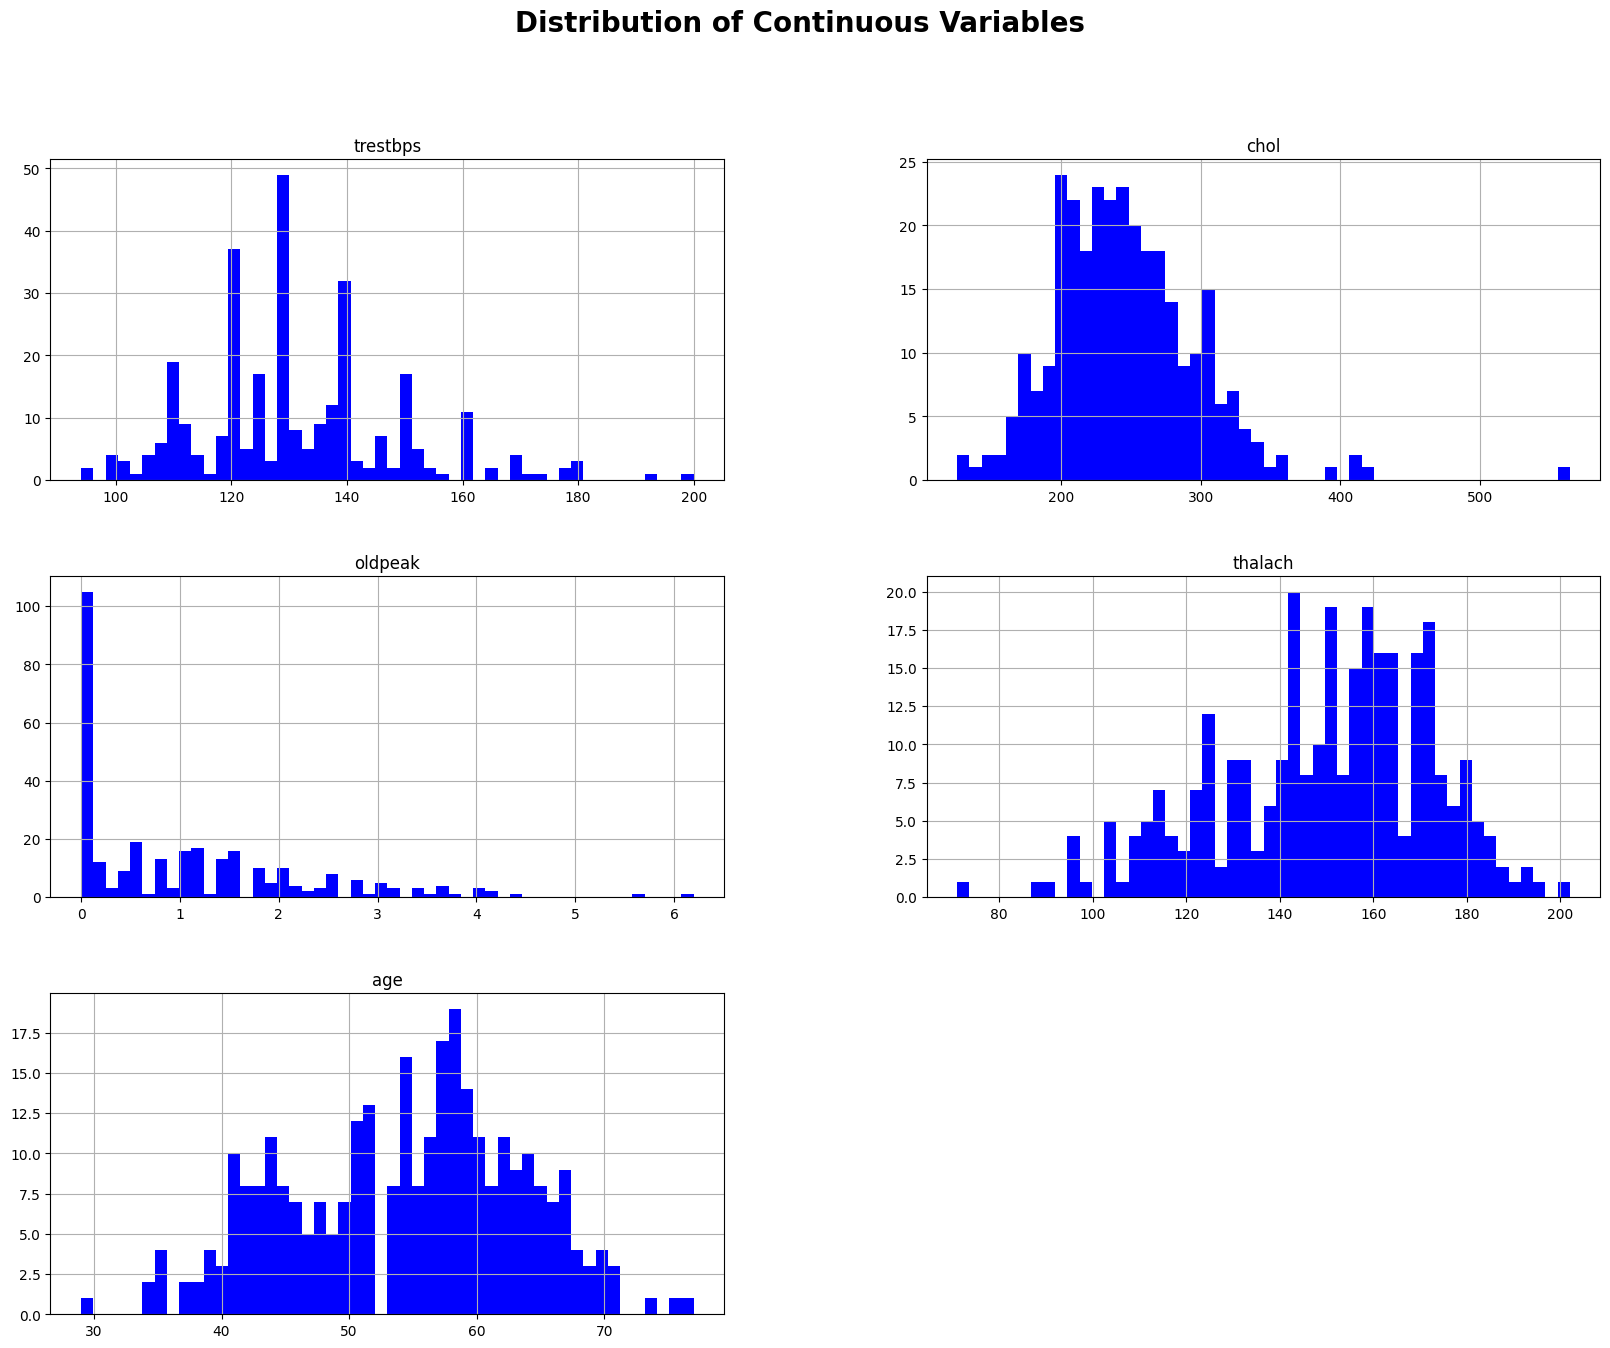

In [14]:
#Initial_Distribution_Check

#Continuous_columns
continuous_cols = df[['trestbps', 'chol', 'oldpeak', 'thalach','age']]

#Histogram
continuous_cols.hist(bins=50, figsize=(20, 15), color='blue')
plt.suptitle("Distribution of Continuous Variables", fontsize=20, fontweight='bold')
plt.show()


#### Pairwise Relationships Between Continuous Variables

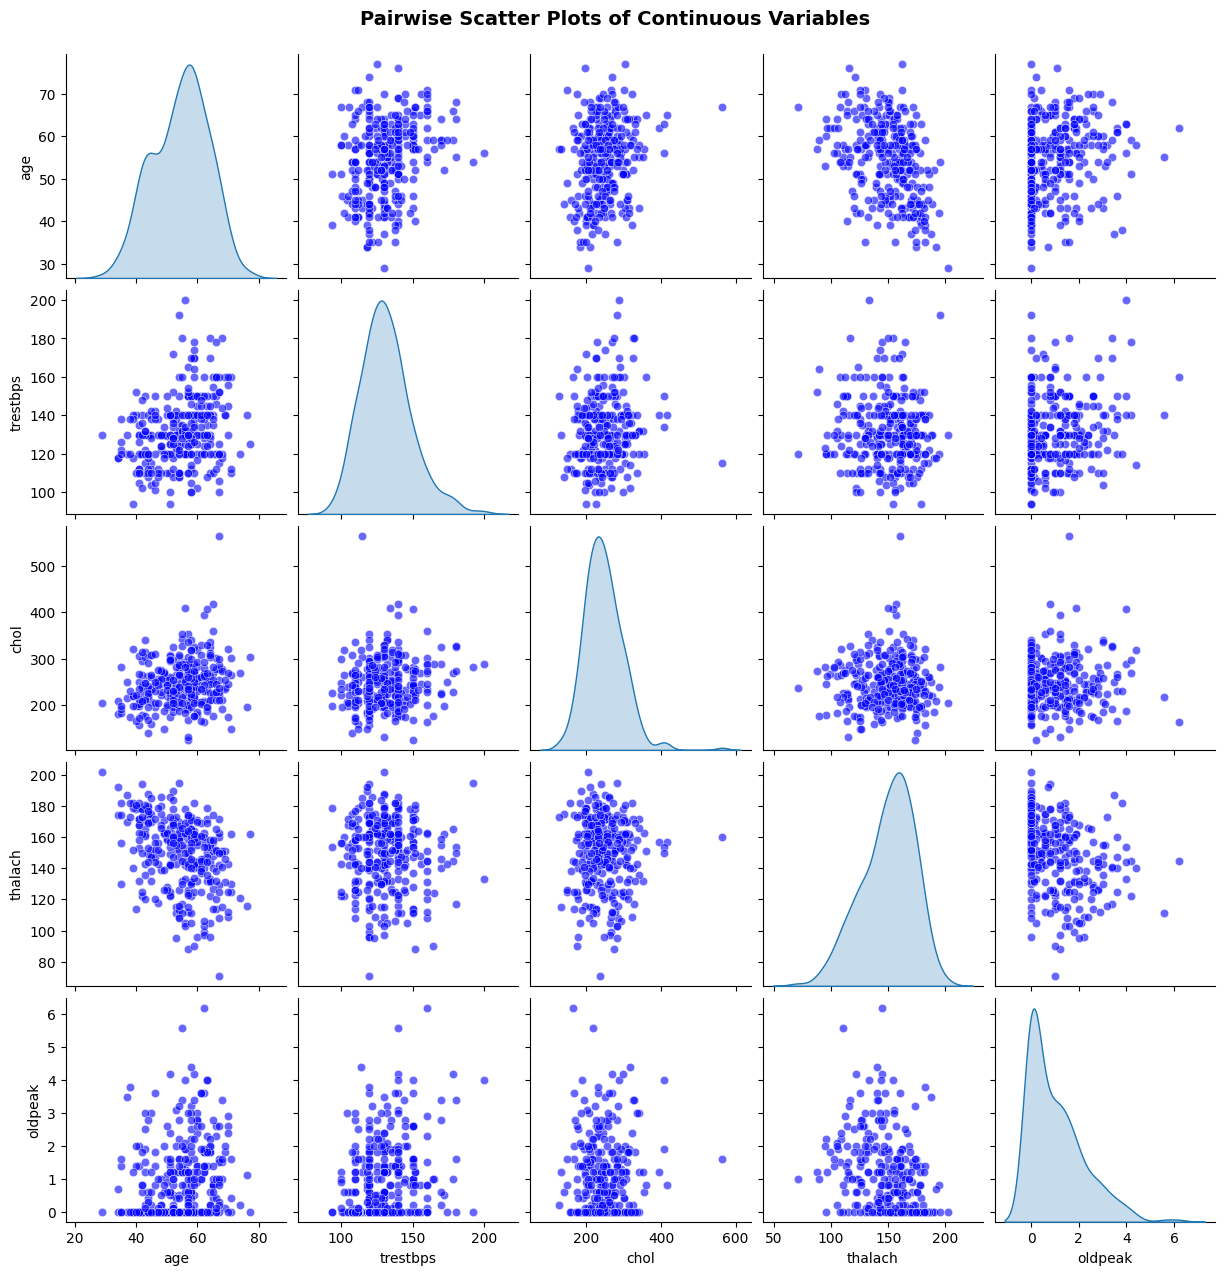

In [15]:
#Scatter_Plot

continuous_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
sns.pairplot(df[continuous_columns], diag_kind='kde', plot_kws={'alpha':0.6, 'color':'blue'})
plt.suptitle("Pairwise Scatter Plots of Continuous Variables", fontsize=14, fontweight='bold', y=1.02)

plt.show()

Pairwise scatter plots are used to examine the relationships and distributions of the continuous variables and to identify potential unusual observations.

## Exploratory Data Analysis

### Heart Disease Distribution

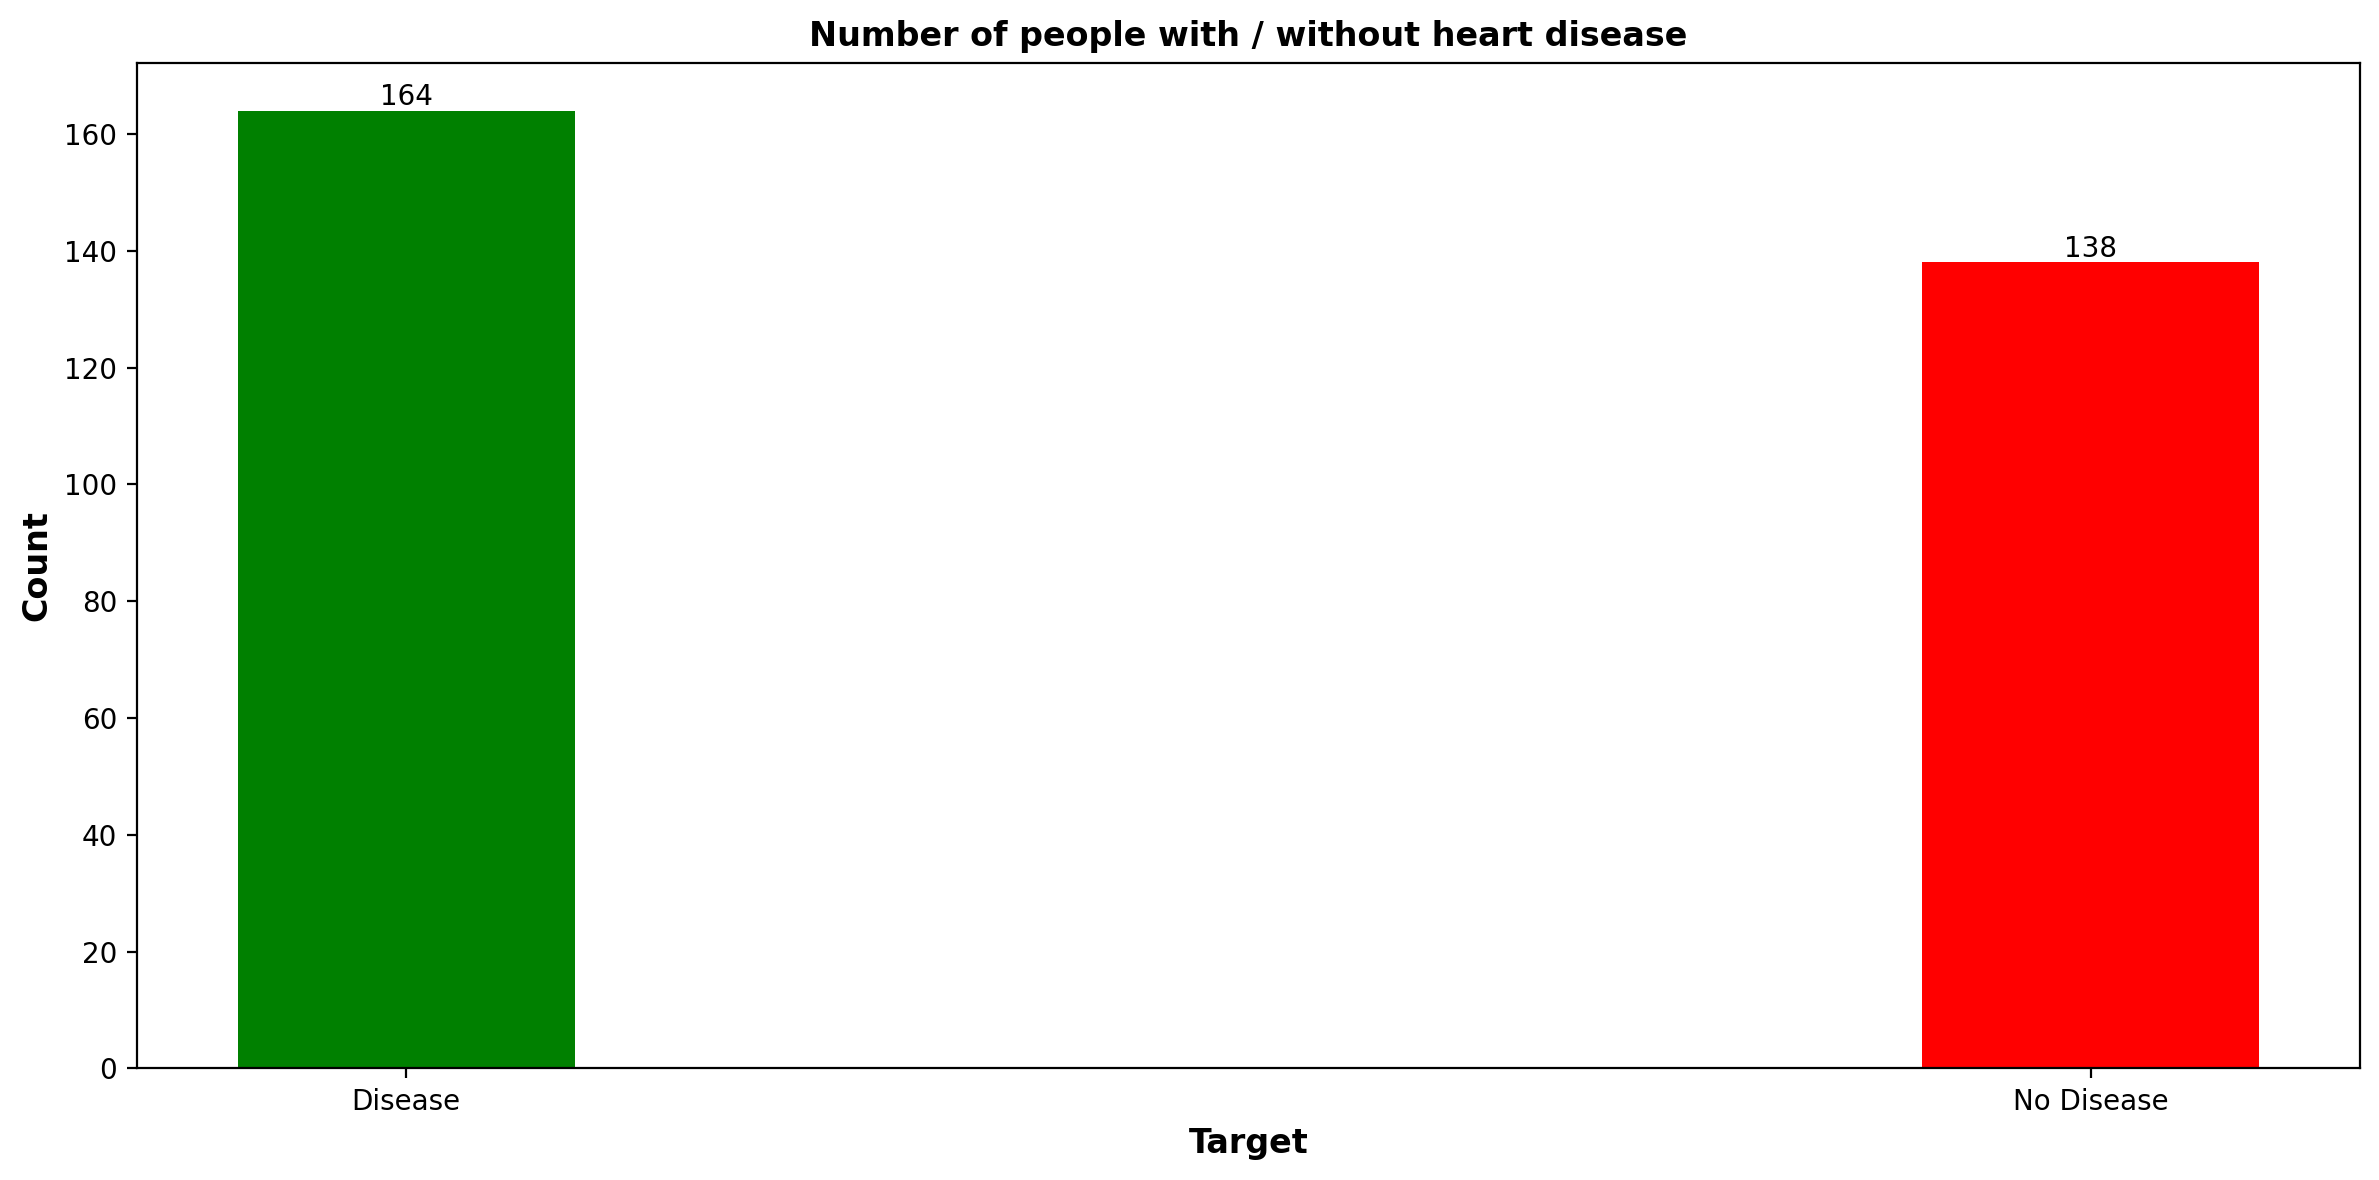

In [16]:
#Mapping
df['disease_label'] = df['target'].map({0: 'No Disease', 1: 'Disease'})

#Count
counts = df['disease_label'].value_counts()

#Colour
colors = ['green', 'red']

#SubPlot
fig, ax = plt.subplots(figsize=(12,6), dpi=200)
bars = ax.bar(counts.index, counts.values, color=colors, width=0.2)

#Add_number_top_of_bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{int(height)}', ha='center')


ax.set_title('Number of people with / without heart disease', fontweight='bold', fontsize=12)
ax.set_xlabel('Target', fontweight='bold', fontsize=12)
ax.set_ylabel('Count', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

The dataset contains 164 patients with heart disease and 138 patients without heart disease after duplicate records were removed. The two groups are relatively balanced, although the disease group is slightly larger.

### Age Distribution by Sex

The age distribution is examined across male and female participants to understand the demographic composition of the dataset and identify differences in the observed age ranges.


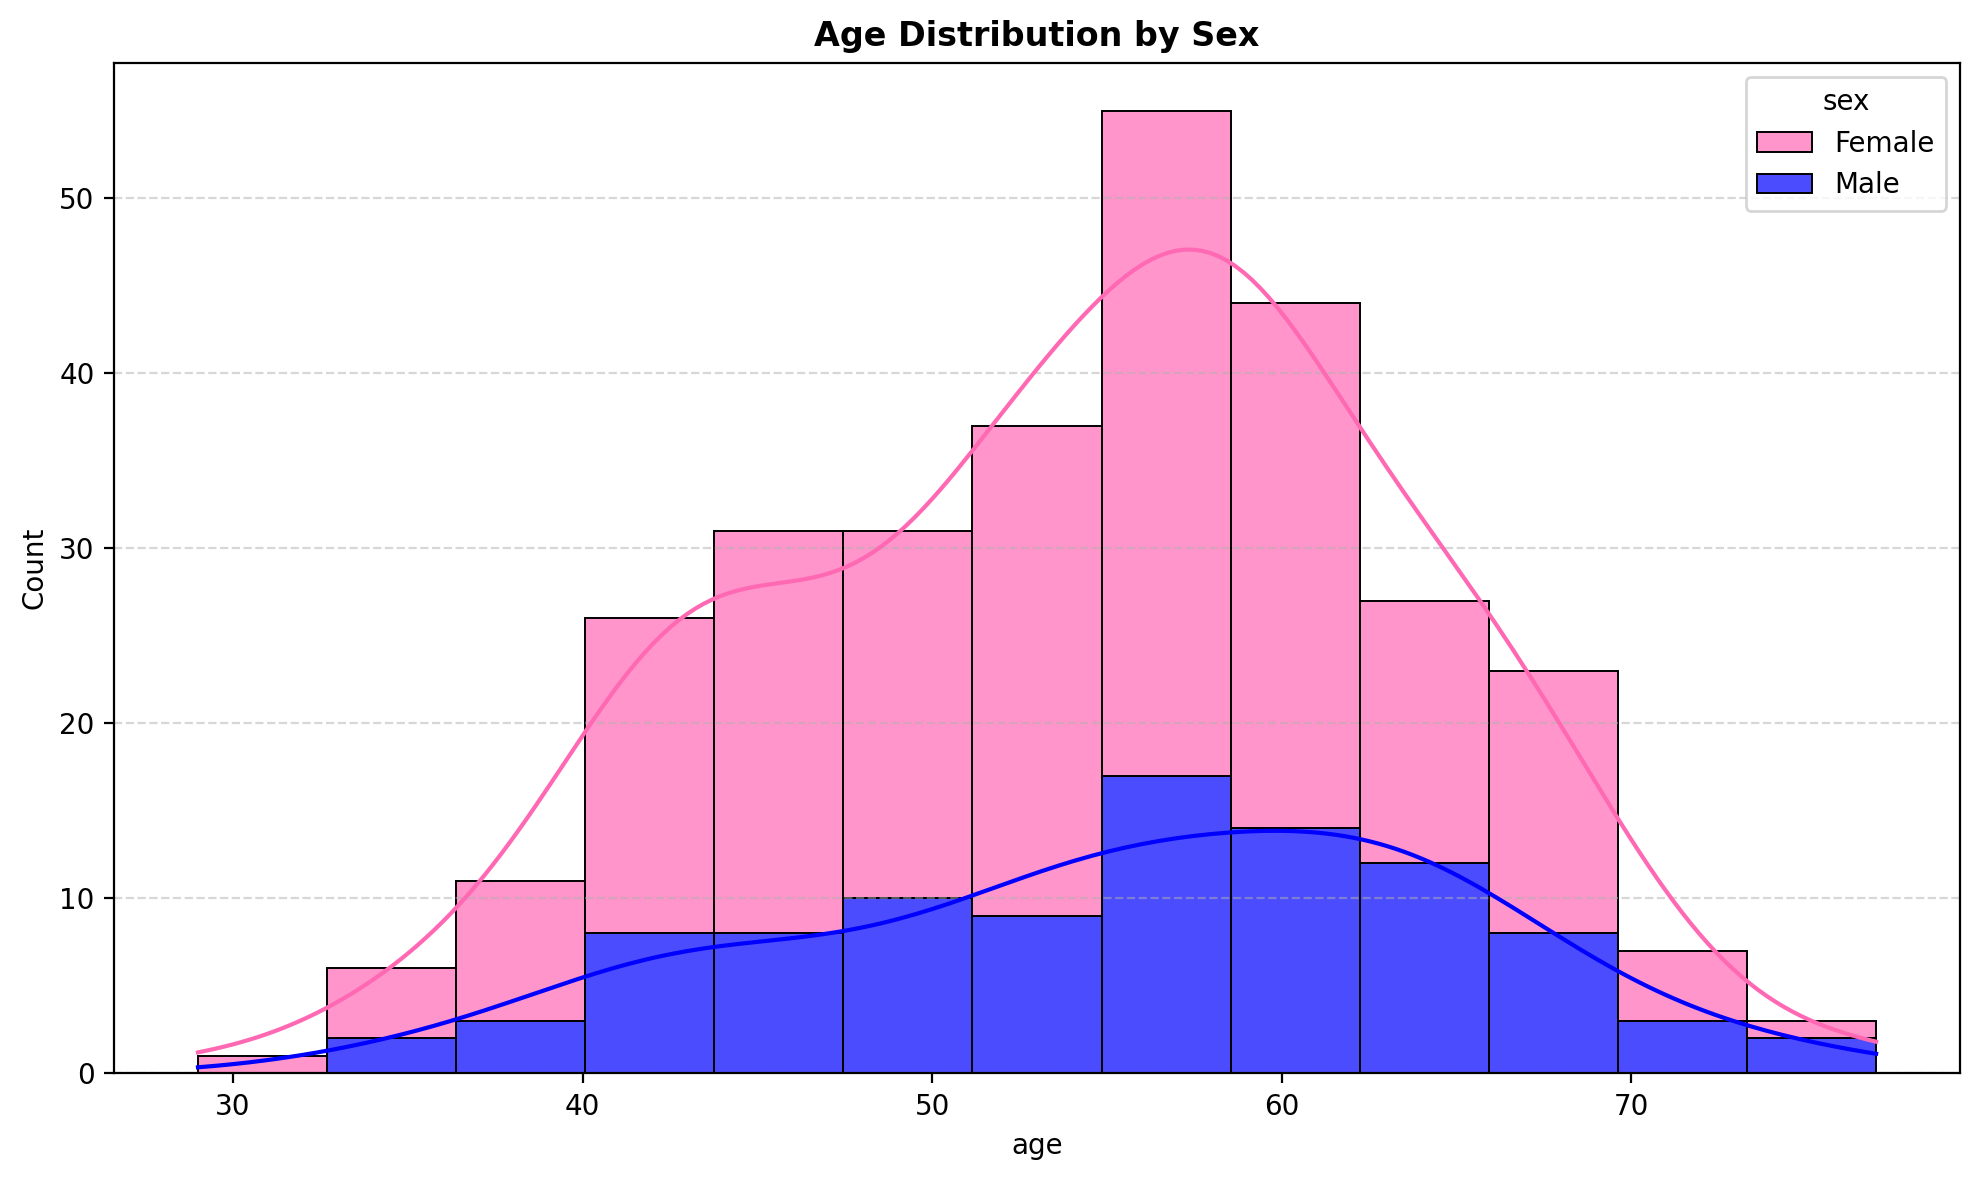

In [17]:

df_plot = df.copy()
df_plot['sex'] = df_plot['sex'].map({0: 'Male', 1: 'Female'})

#Histogram
plt.figure(figsize=(10,6), dpi=200) 

sns.histplot(data=df_plot, x='age', hue='sex', palette={'Male': 'blue', 'Female': 'hotpink'},
             kde=True, multiple='stack', edgecolor='black', linewidth=0.7, alpha=0.7  )


plt.title('Age Distribution by Sex', fontsize=12, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The age distribution is examined across male and female participants to understand the demographic composition of the dataset and identify differences in the observed age ranges.

### Heart Disease Distribution by Sex

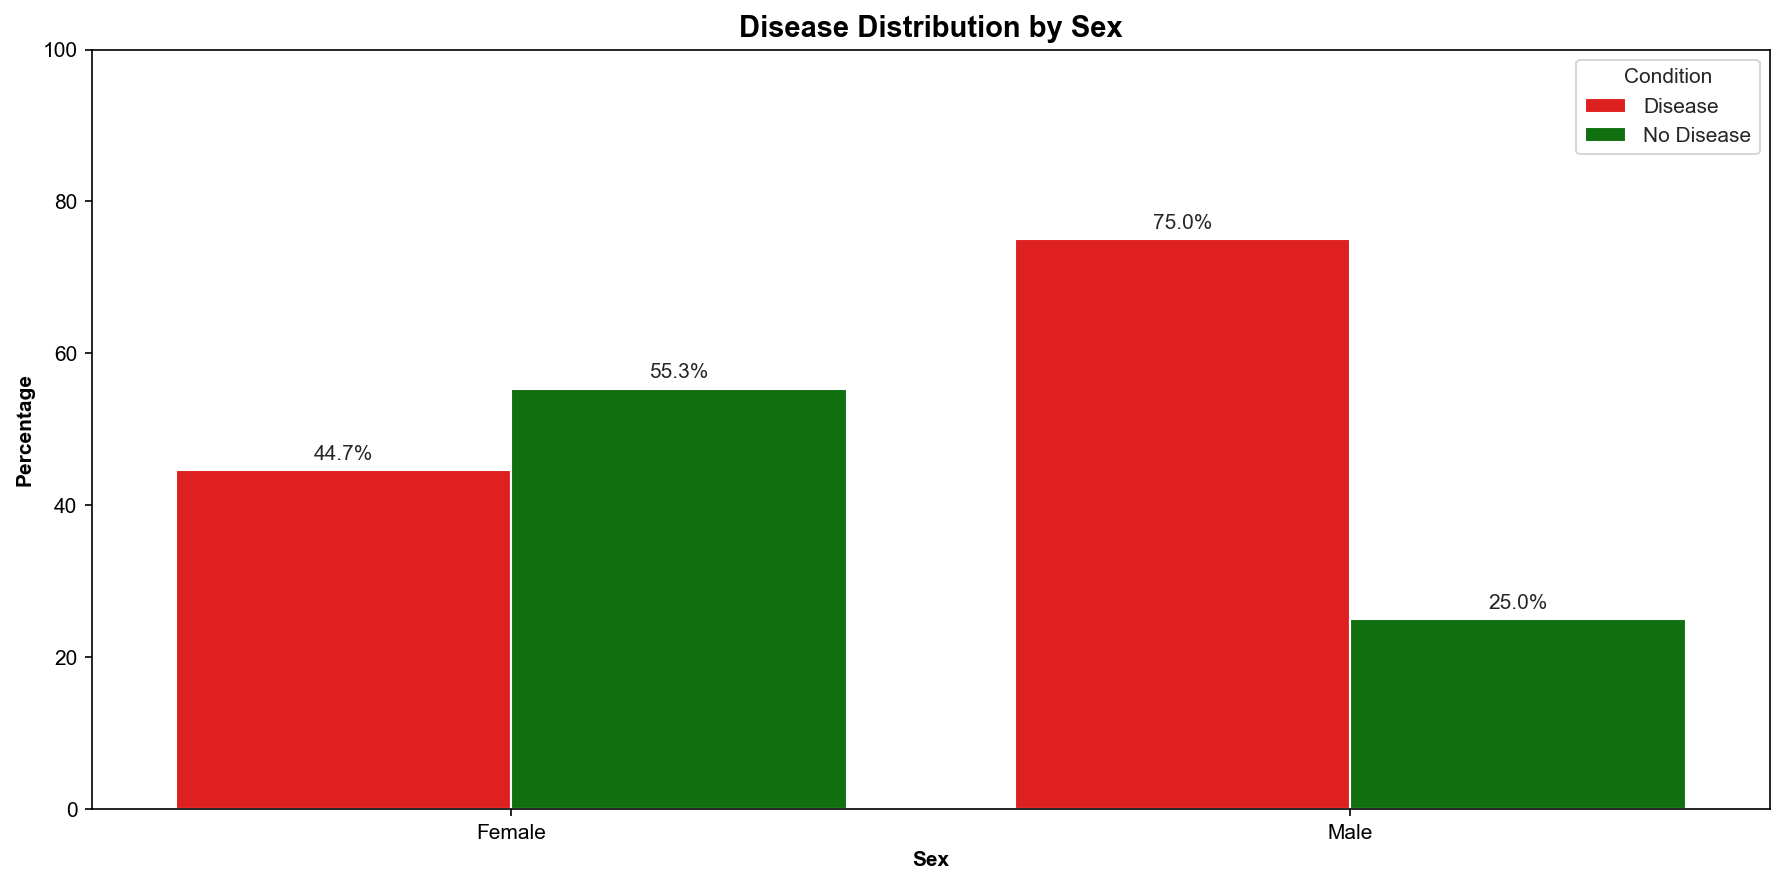

In [18]:

#Mapping
df['sex_label'] = df['sex'].map({0: 'Male', 1: 'Female'})
df['disease_label'] = df['target'].map({0: 'No Disease', 1: 'Disease'})

#Percentage
percent_df = pd.crosstab(df['sex_label'], df['disease_label'], normalize='index') * 100
percent_df = percent_df.reset_index().melt(id_vars='sex_label', var_name='Disease', value_name='Percentage')

#Colour
custom_palette = {
    'No Disease': 'green',
    'Disease': 'red'
}

fig, ax = plt.subplots(figsize=(12,6), dpi=150)

#BarPlot
sns.set_style("whitegrid")
ax = sns.barplot(
    data=percent_df,
    x='sex_label',
    y='Percentage',
    hue='Disease',
    palette=custom_palette
)

plt.title('Disease Distribution by Sex', fontsize=14,fontweight='bold')
plt.ylabel('Percentage',fontweight='bold'),
plt.xlabel('Sex',fontweight='bold')
plt.ylim(0, 100)
plt.legend(title='Condition')
plt.tight_layout()

#Show_Percentage_on_Bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

The proportion of participants with heart disease differs between males and females in this dataset. A larger proportion of male participants are classified as having heart disease compared with female participants. This pattern describes the sample and should not be interpreted as a causal relationship or as representative of the general population.

### Age vs Heart Disease


The age distributions of participants with and without heart disease are compared to identify whether the two groups show noticeable differences in their observed age ranges and central tendency.

#### Histogram

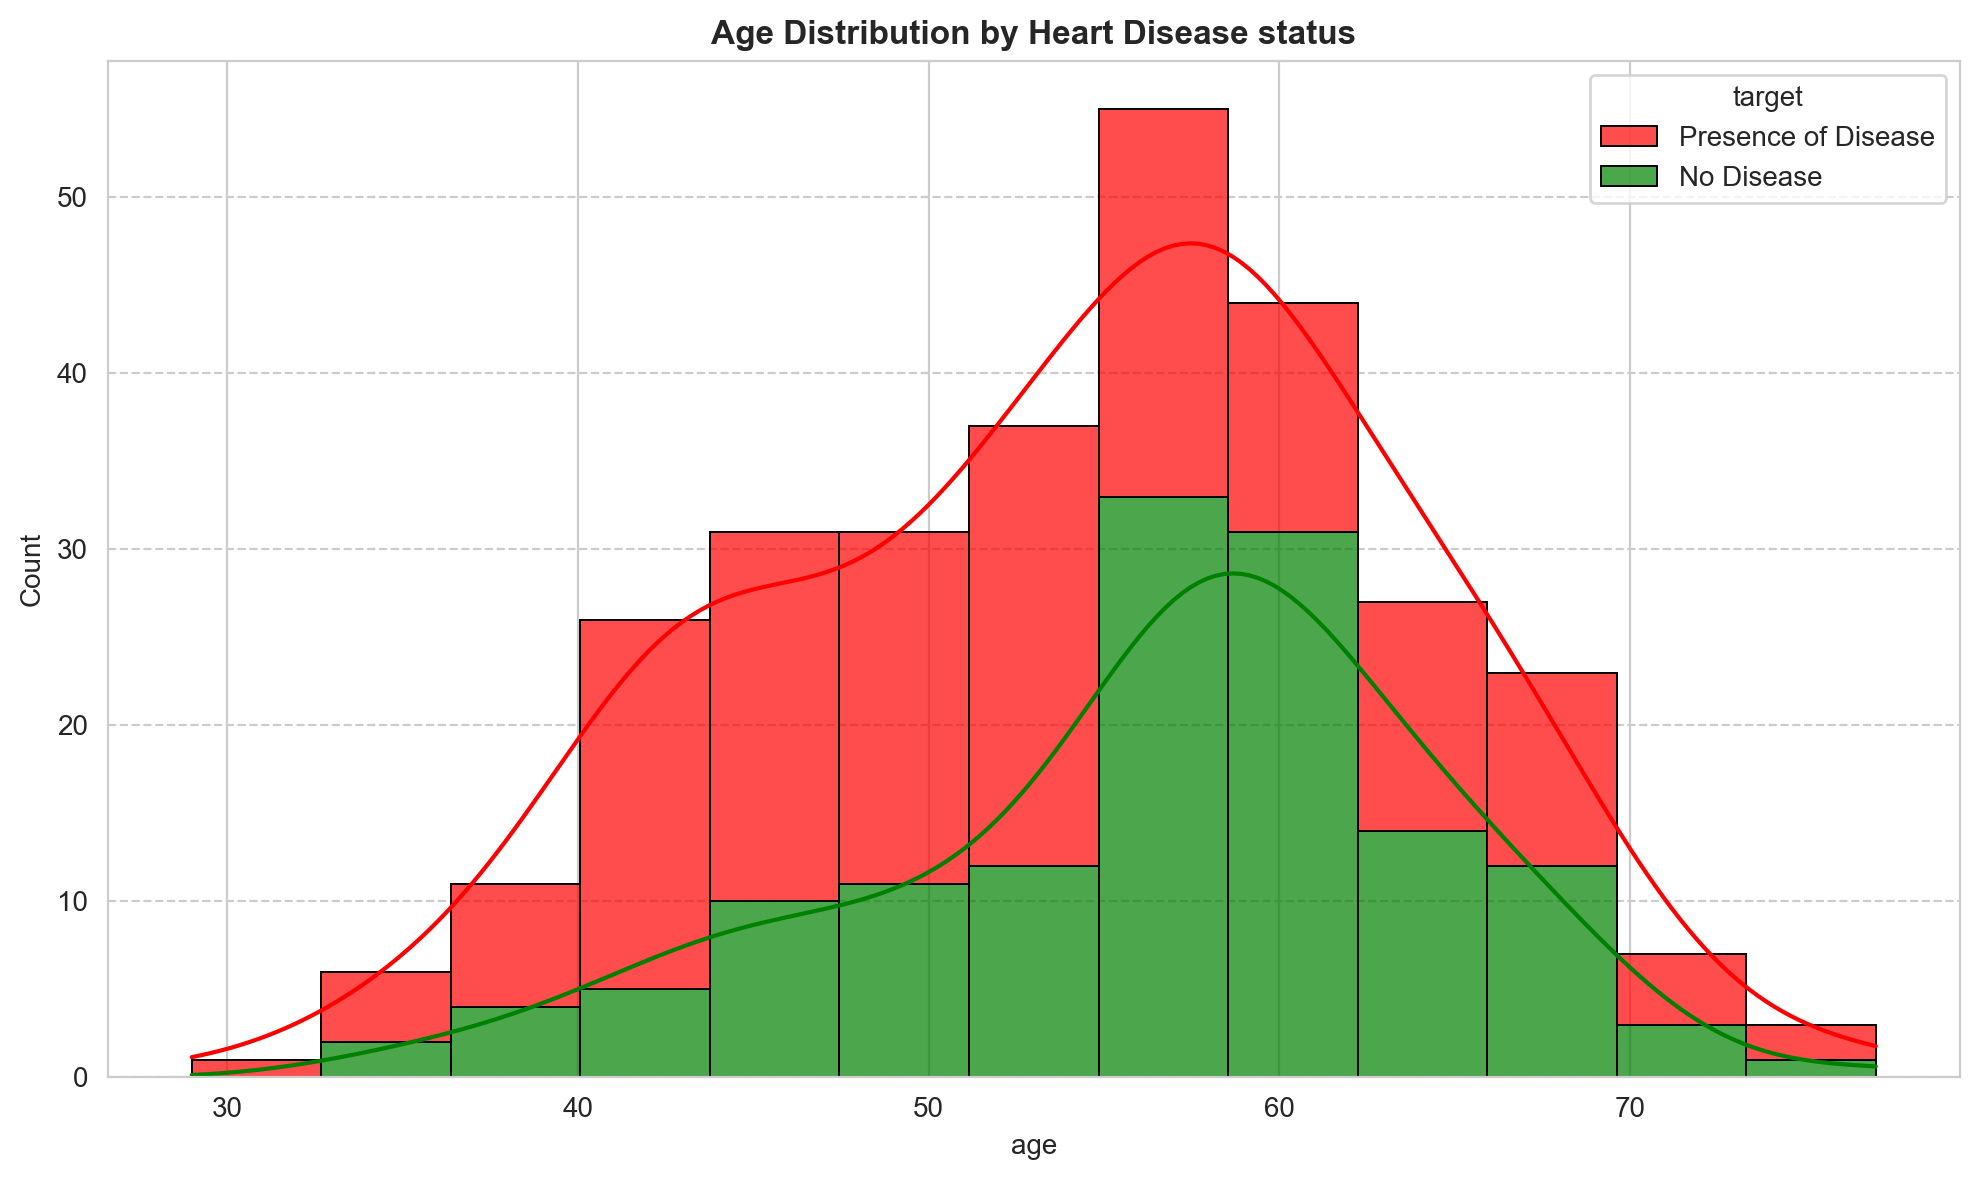

In [19]:

df_plot = df.copy()
df_plot['target'] = df_plot['target'].map({0: 'No Disease', 1: 'Presence of Disease'})

#Histogram
plt.figure(figsize=(10,6), dpi=200) 

sns.histplot(data=df_plot, x='age', hue='target', palette={'No Disease': 'green', 'Presence of Disease': 'red'},
             kde=True, multiple='stack', edgecolor='black', linewidth=0.7, alpha=0.7  )

plt.title('Age Distribution by Heart Disease status', fontsize=12, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=1)

plt.tight_layout()
plt.show()

#### Box Plot

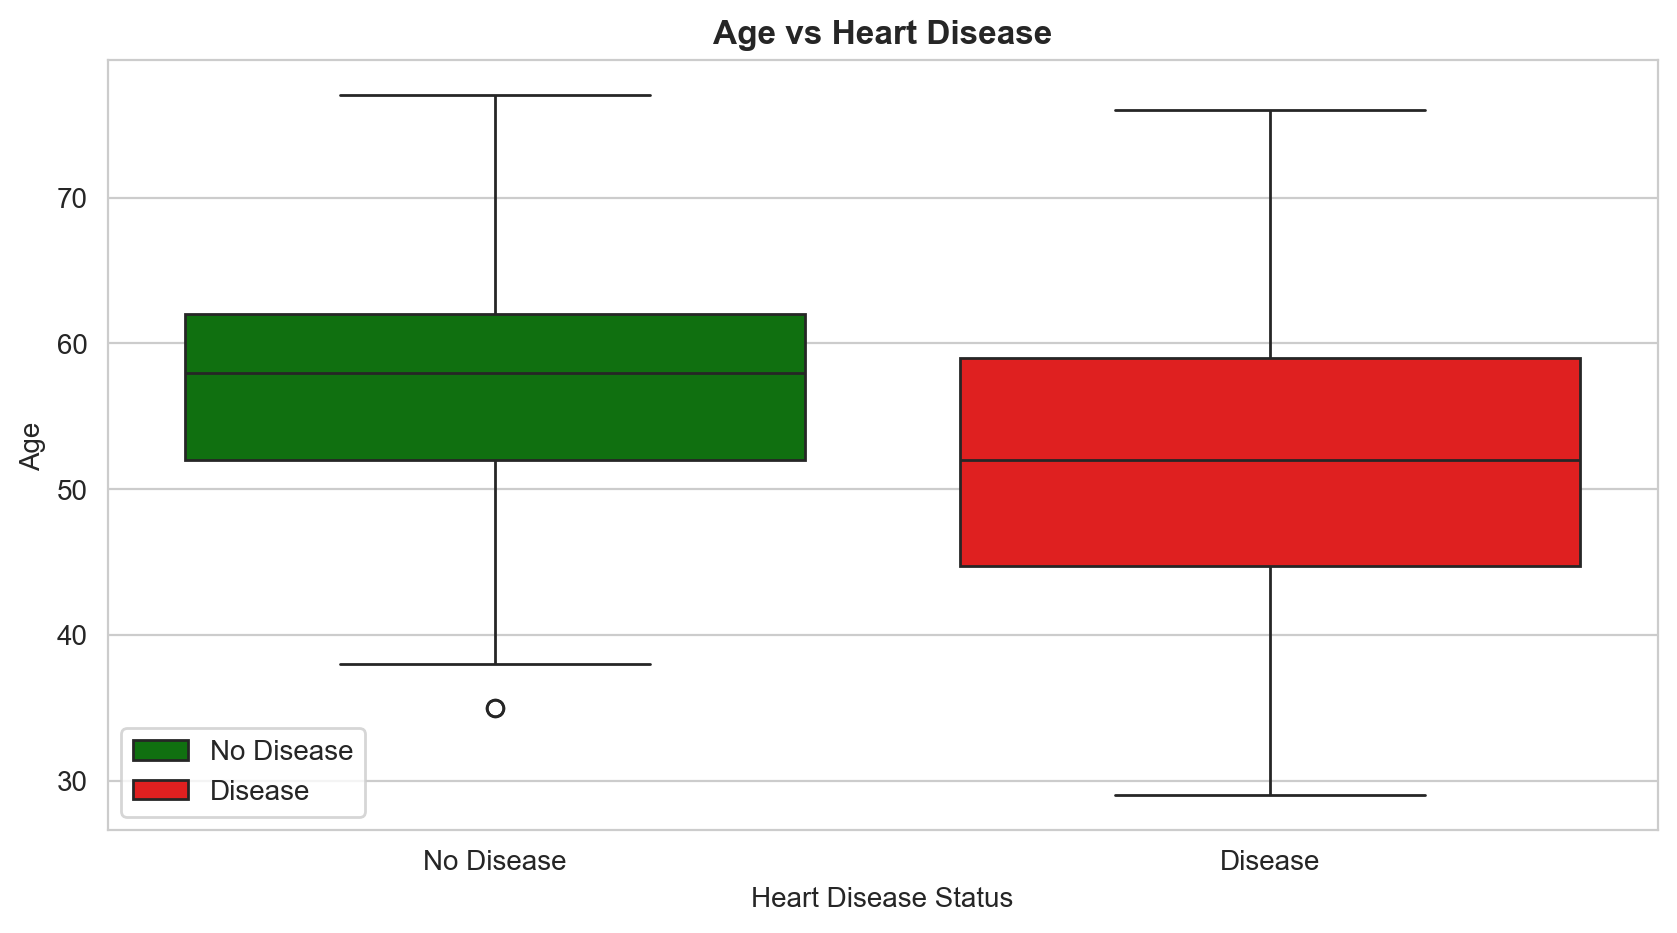

In [20]:

plt.figure(figsize=(10,5), dpi=200)
sns.boxplot(x='target', y='age', data=df, hue='target', palette=['green', 'red'])

plt.title('Age vs Heart Disease',fontsize=12, fontweight='bold')
plt.xticks([0,1], ['No Disease', 'Disease'])
plt.xlabel('Heart Disease Status')
plt.ylabel('Age')
plt.legend(['No Disease', 'Disease'], frameon=True)

plt.show()


The distributions overlap substantially, indicating that age alone does not clearly separate the two groups in this dataset.

We expected that as age increases, the number of heart disease patients would also increase, but the data doesn't show that pattern clearly. One possible explanation is that with increasing age, people tend to visit doctors more frequently for heart checkups, so more data is recorded for older individuals. This means that among older age groups, there are both healthy people and patients, but for younger age groups, either symptoms were less obvious, or due to genetic factors and family history, some cases were followed up more closely. Therefore, the number of patients in older age groups might be higher than expected, and the data doesn't perfectly match our initial expectations.

In summary, the difference between the actual population and what we expected should be taken into account, so we shouldn’t just look at the raw numbers.

### Chest Pain Type and Heart Disease Status

The distribution of chest pain types is compared between participants with and without heart disease to examine whether certain chest pain categories are more frequently observed in either group.


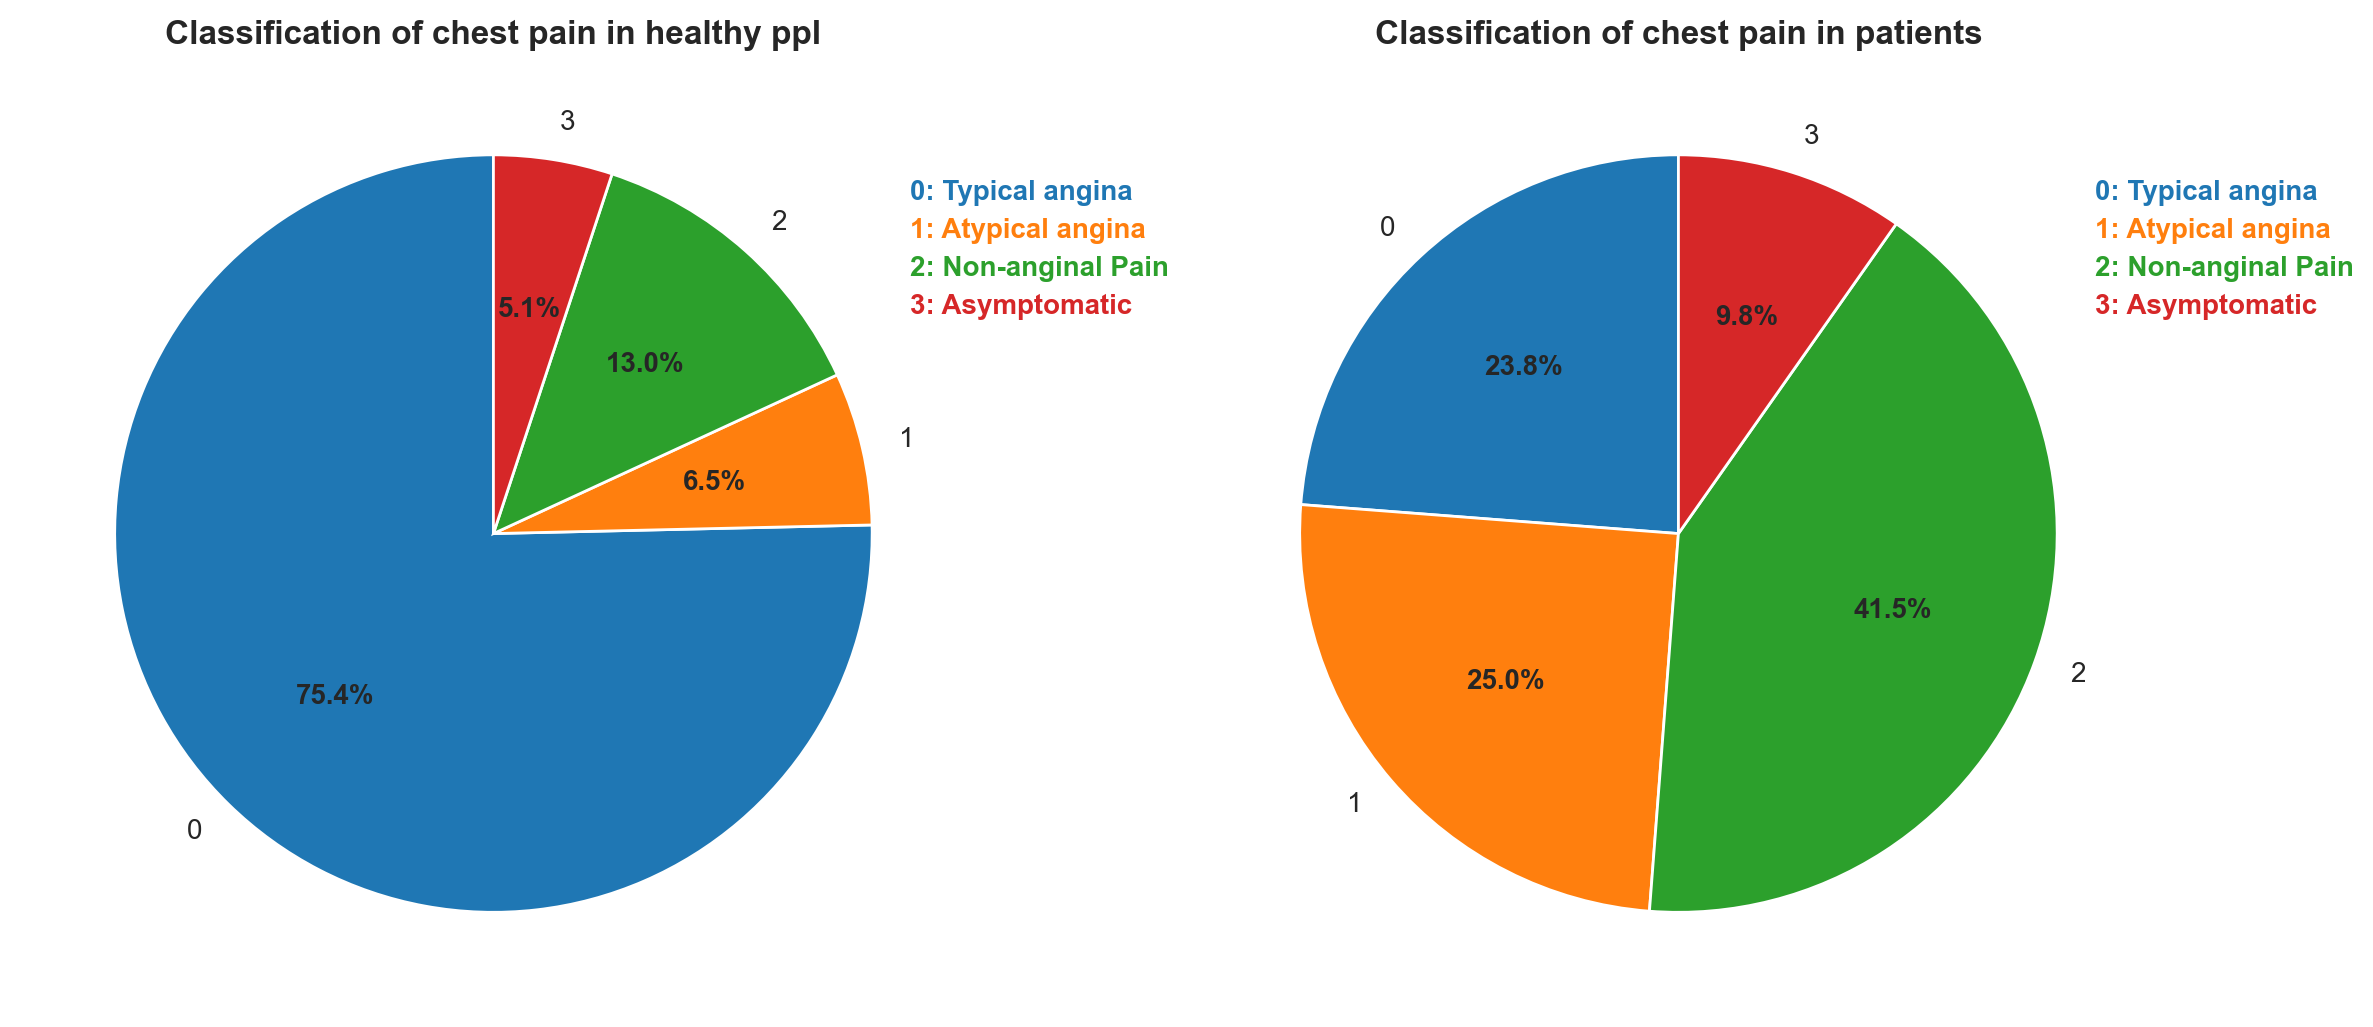

In [21]:
df_healthy = df[df["target"]==0]
df_patient = df[df["target"]==1]

#Types_of_chest_pain_ib_Both_healthy_and_patient_ones

counts1 = df_healthy['cp'].value_counts().sort_index()
counts2 = df_patient['cp'].value_counts().sort_index()

labels_text = ['0: Typical angina', '1: Atypical angina', '2: Non-anginal Pain', '3: Asymptomatic']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

#Colors

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

#PiePlot_for_healthy_df

wedges1, texts1, autotexts1 = axes[0].pie(counts1, labels=counts1.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Classification of chest pain in healthy ppl', fontweight='bold')

#Bold_Percentage
for autotext in autotexts1:
    autotext.set_fontweight('bold')

#label1

for i, text in enumerate(labels_text):
    axes[0].text(1.1, 0.9 - i*0.1, text, color=colors[i], fontsize=10, va='center',fontweight='bold')

#PiePlot_for_patient_df
wedges2, texts2, autotexts2 = axes[1].pie(counts2, labels=counts2.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Classification of chest pain in patients', fontweight='bold')

#Bold_Percentage
for autotext in autotexts2:
    autotext.set_fontweight('bold')


#label2
for i, text in enumerate(labels_text):
    axes[1].text(1.1, 0.9 - i*0.1, text, color=colors[i], fontsize=10, va='center',fontweight='bold')

plt.tight_layout()
plt.show()

### Chest Pain by Age Group

In [22]:
df_under_55 = df[df['age'] <= 55]
df_above_55 = df[df['age'] > 55]

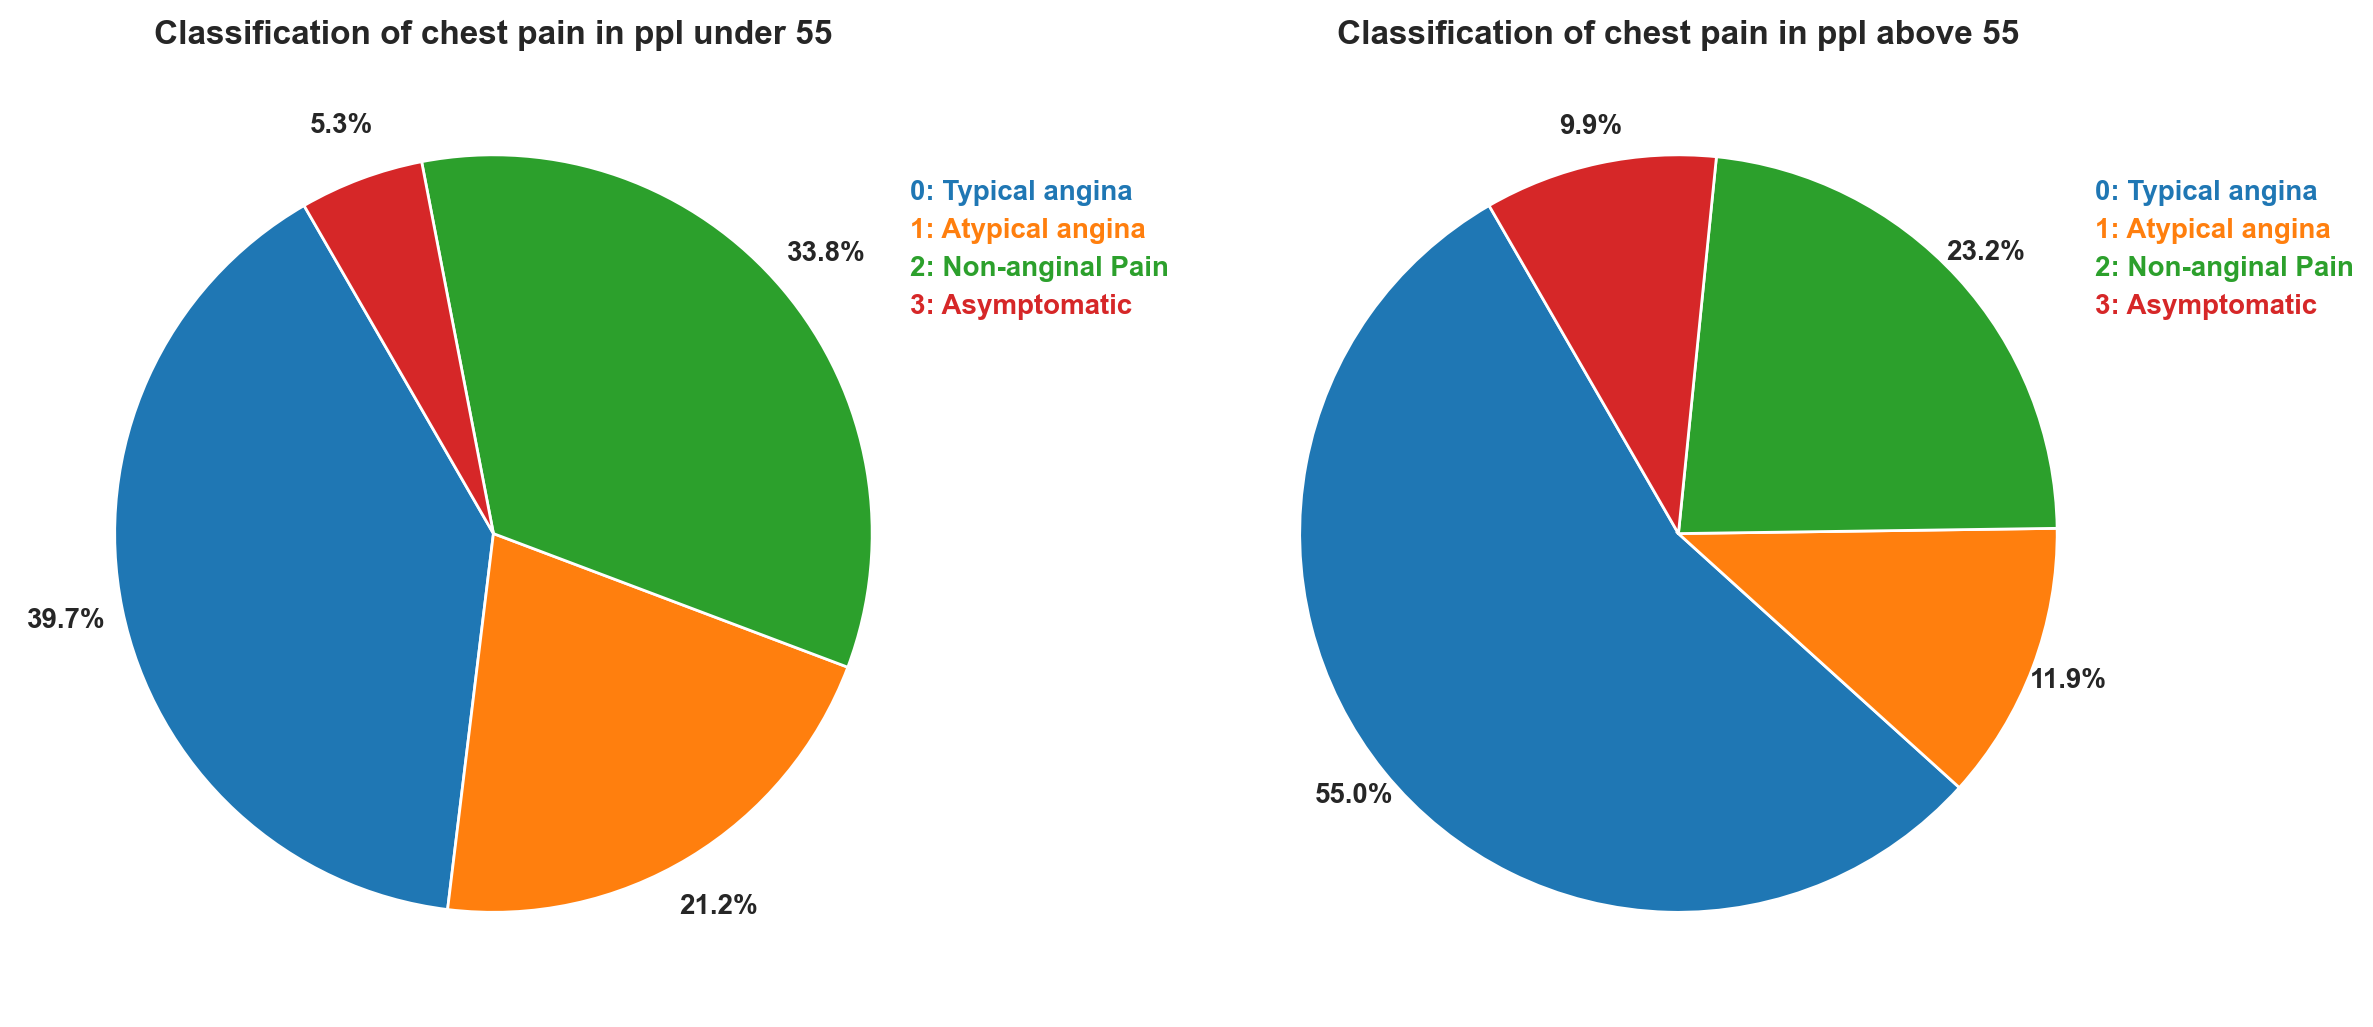

In [23]:
#Classification of chest pain in ppl under/above 55

counts11 = df_under_55['cp'].value_counts().sort_index()
counts22 = df_above_55['cp'].value_counts().sort_index()

labels_text = ['0: Typical angina', '1: Atypical angina', '2: Non-anginal Pain', '3: Asymptomatic']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

#Colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

#PiePlot_for_healthy_df
wedges1, texts1, autotexts1 = axes[0].pie(counts11, labels=None, autopct='%1.1f%%',pctdistance=1.15, startangle=120, colors=colors)
axes[0].set_title('Classification of chest pain in ppl under 55', fontweight='bold')

#Bold_Percentage
for autotext in autotexts1:
    autotext.set_fontweight('bold')

#label1
for i, text in enumerate(labels_text):
    axes[0].text(1.1, 0.9 - i*0.1, text, color=colors[i], fontsize=10, va='center',fontweight='bold')

#PiePlot_for_patient_df
wedges2, texts2, autotexts2 = axes[1].pie(counts22, labels=None, autopct='%1.1f%%', pctdistance=1.1, startangle=120, colors=colors)
axes[1].set_title('Classification of chest pain in ppl above 55', fontweight='bold')

#Bold_Percentage
for autotext in autotexts2:
    autotext.set_fontweight('bold')

#label2
for i, text in enumerate(labels_text):
    axes[1].text(1.1, 0.9 - i*0.1, text, color=colors[i], fontsize=10, va='center',fontweight='bold')

plt.tight_layout()
plt.show()

### Thalium Stress Test and Heart Disease

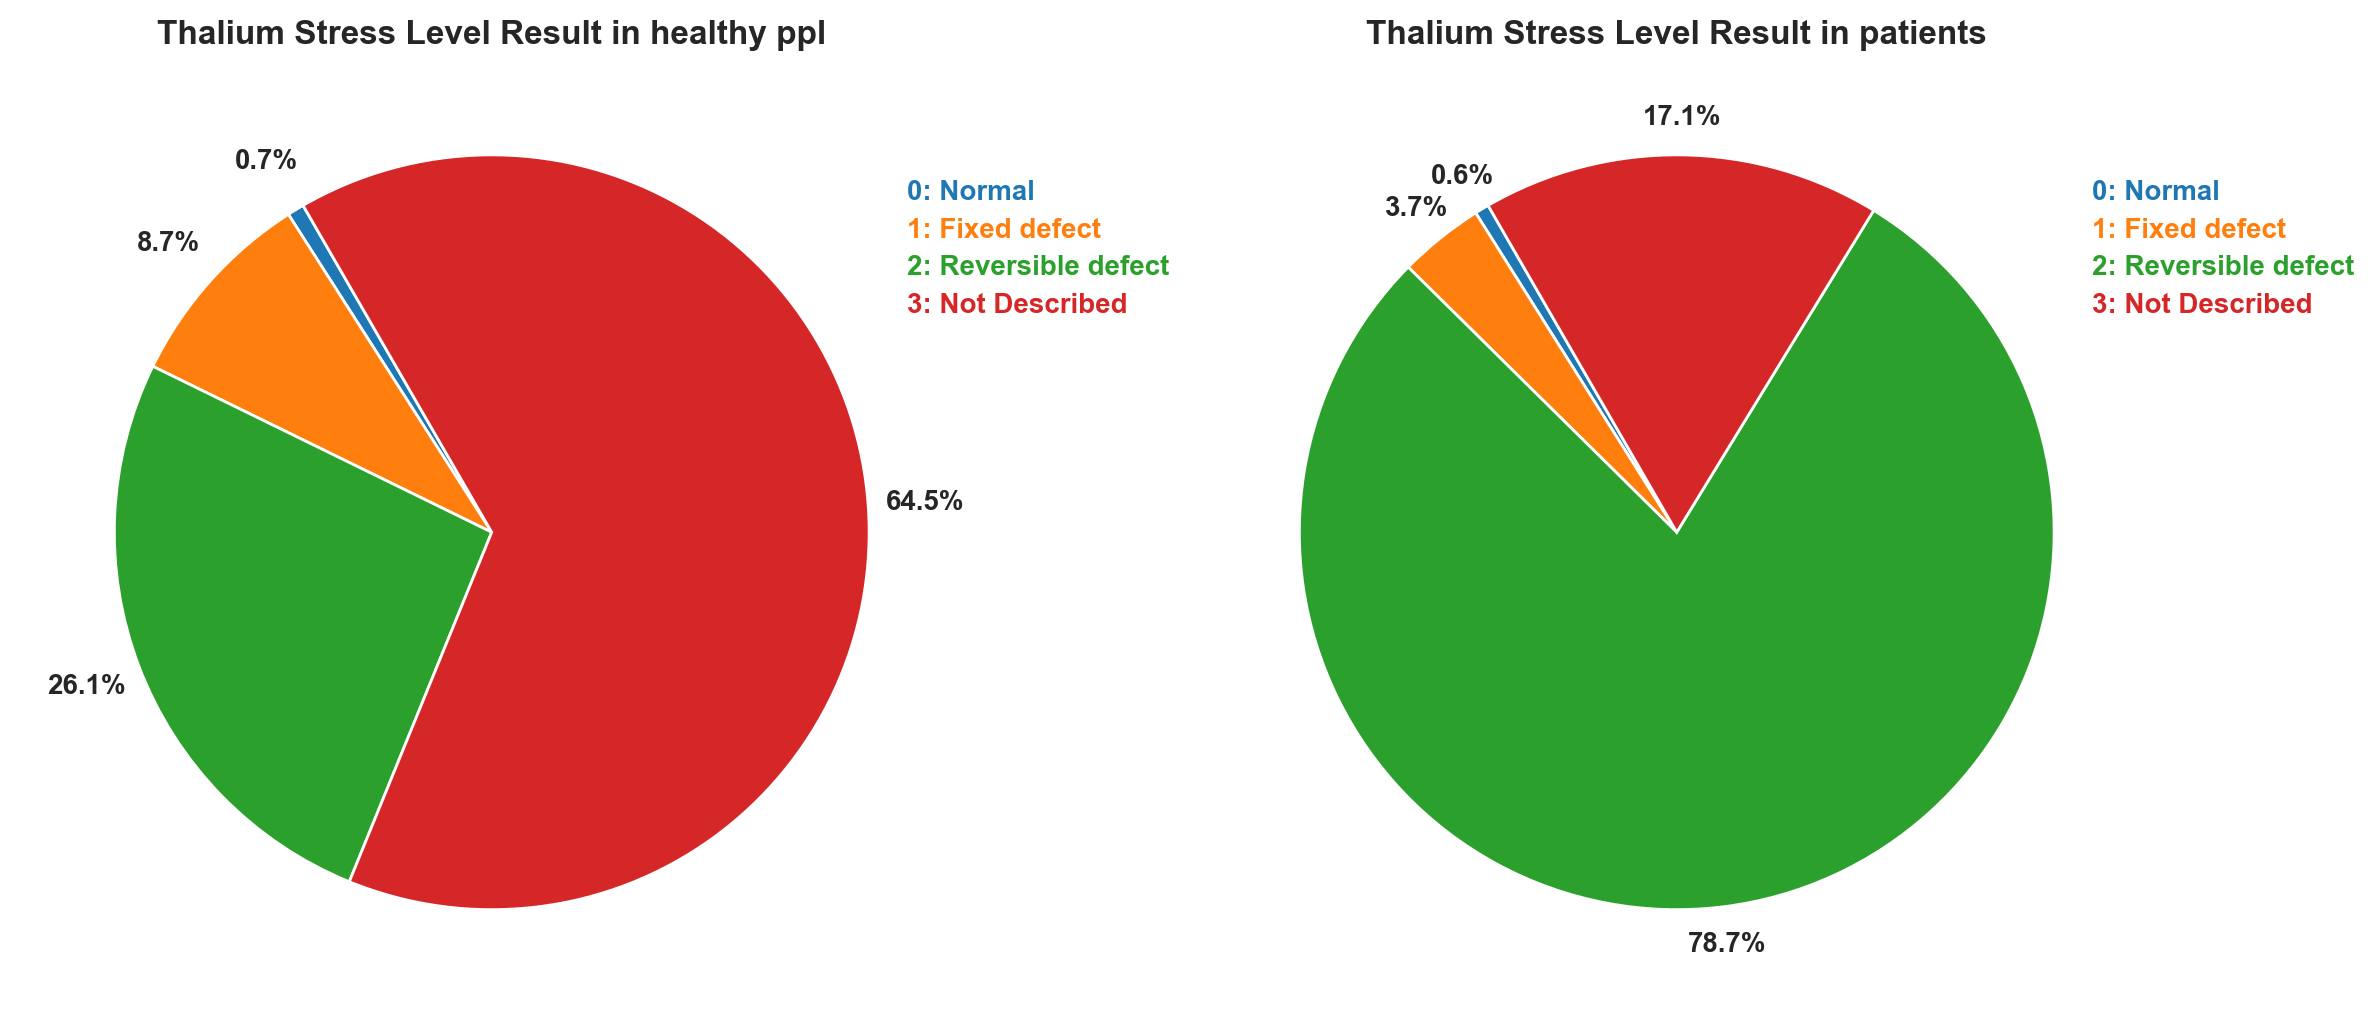

In [24]:
#Thalium Stress Level Result in both healthy ppl & patients

counts1 = df_healthy['thal'].value_counts().sort_index()
counts2 = df_patient['thal'].value_counts().sort_index()

labels_text = ['0: Normal', '1: Fixed defect', '2: Reversible defect', '3: Not Described']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

#Colors

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

#PiePlot_for_healthy_df

wedges1, texts1, autotexts1 = axes[0].pie(counts1, labels=None, autopct='%1.1f%%',pctdistance=1.15, startangle=120, colors=colors)
axes[0].set_title('Thalium Stress Level Result in healthy ppl', fontweight='bold')


#Bold_Percentage
for autotext in autotexts1:
     autotext.set_fontweight('bold')

#label1

for i, text in enumerate(labels_text):
    axes[0].text(1.1, 0.9 - i*0.1, text, color=colors[i], fontsize=10, va='center',fontweight='bold')

#PiePlot_for_patient_df
wedges2, texts2, autotexts2 = axes[1].pie(counts2, labels=None, autopct='%1.1f%%', pctdistance=1.1, startangle=120, colors=colors)
axes[1].set_title('Thalium Stress Level Result in patients', fontweight='bold')

#Bold_Percentage
for autotext in autotexts2:
     autotext.set_fontweight('bold')


#label2
for i, text in enumerate(labels_text):
    axes[1].text(1.1, 0.9 - i*0.1, text, color=colors[i], fontsize=10, va='center',fontweight='bold')

plt.tight_layout()
plt.show()

The distribution of thalium stress test results differs between the heart disease and no-disease groups. In this dataset, a reversible defect (thal = 2) is observed more frequently among participants with heart disease.
This observation describes an association within the sample and does not establish causation.

### Cholesterol vs Resting Blood Pressure

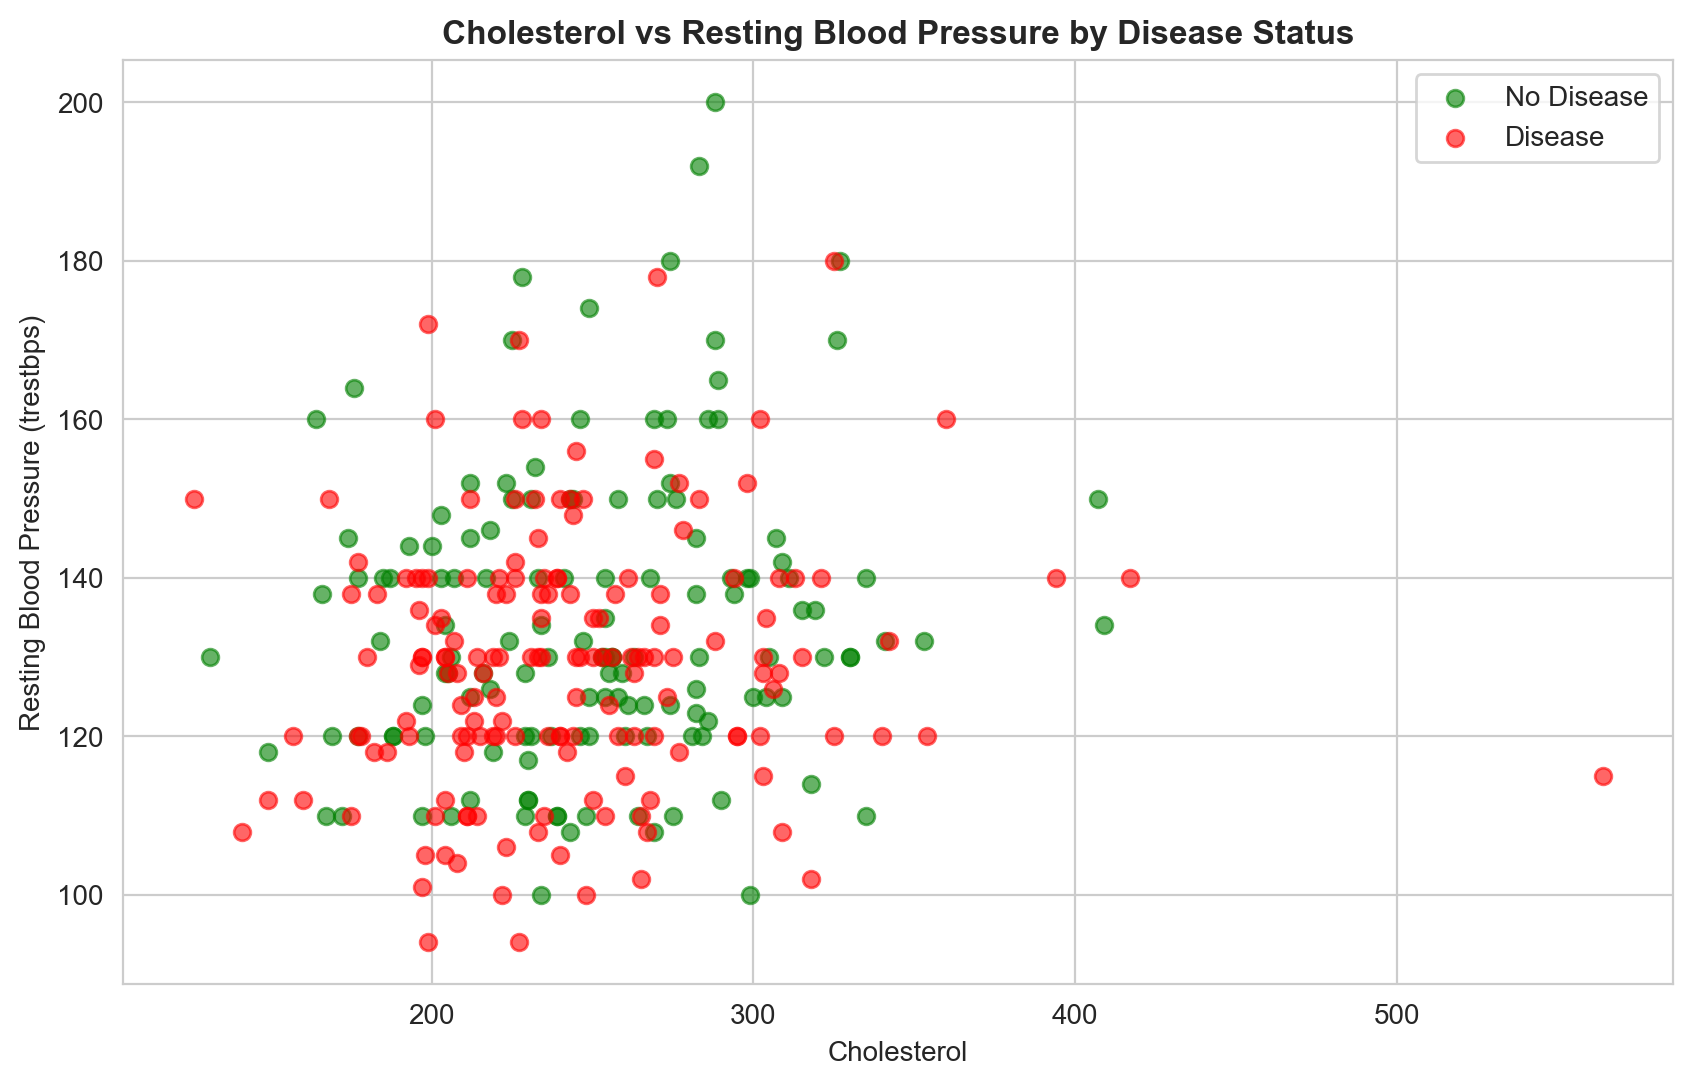

In [25]:
#Potential_Outlier_in_Cholesterol

plt.figure(figsize=(10, 6), dpi=200)
plt.scatter(df_healthy['chol'], df_healthy['trestbps'], color='green', label='No Disease', alpha=0.6)
plt.scatter(df_patient['chol'], df_patient['trestbps'], color='red', label='Disease', alpha=0.6)

plt.title('Cholesterol vs Resting Blood Pressure by Disease Status', fontweight='bold')
plt.xlabel('Cholesterol')
plt.ylabel('Resting Blood Pressure (trestbps)')
plt.legend()
plt.grid(True)

plt.show()

In [26]:
#Potential_Cholesterol_Outlier_Analysis

df[df["chol"]>500]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,disease_label,sex_label
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1,Disease,Male


- A participant with a cholesterol value of 564 mg/dl appears as a potential outlier compared with the rest of the observations.

- This value was retained in the dataset because an unusually high observation should not be removed solely based on its magnitude. 

- Further investigation would be required to determine whether it represents a genuine clinical observation or a data recording issue.


In [27]:
df1=df.drop('disease_label', axis=1)
df1.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'sex_label'],
      dtype='object')

### Age vs Oldpeak

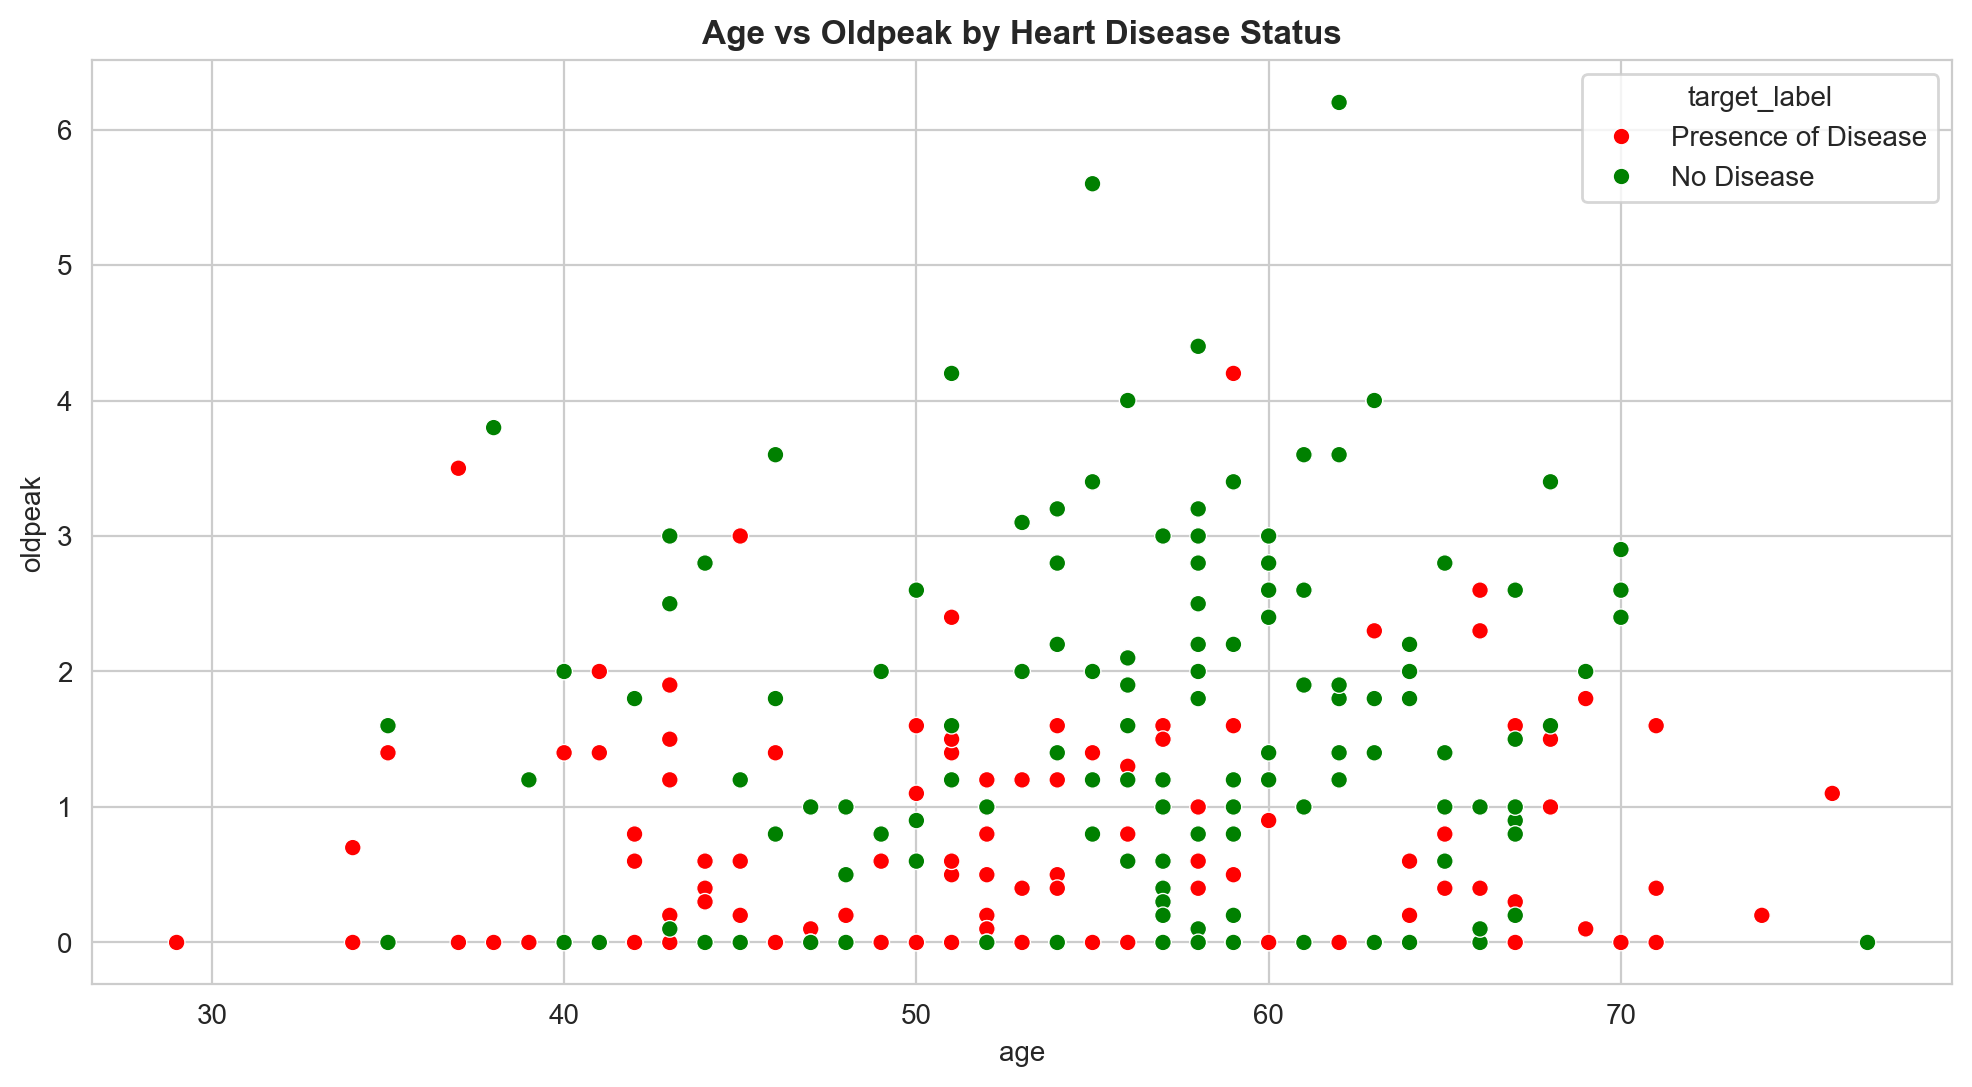

In [28]:
#Scatter_Plot

df1['target_label'] = df1['target'].map({0: 'No Disease', 1: 'Presence of Disease'})
plt.figure(figsize=(12, 6), dpi=200) 

#LinePlot
sns.scatterplot(x='age', y='oldpeak', hue='target_label', data=df1,
             palette={'No Disease': 'green', 'Presence of Disease': 'red'})

plt.title('Age vs Oldpeak by Heart Disease Status', fontweight='bold')
plt.show()


### Number of major vessels and Heart Disease Status

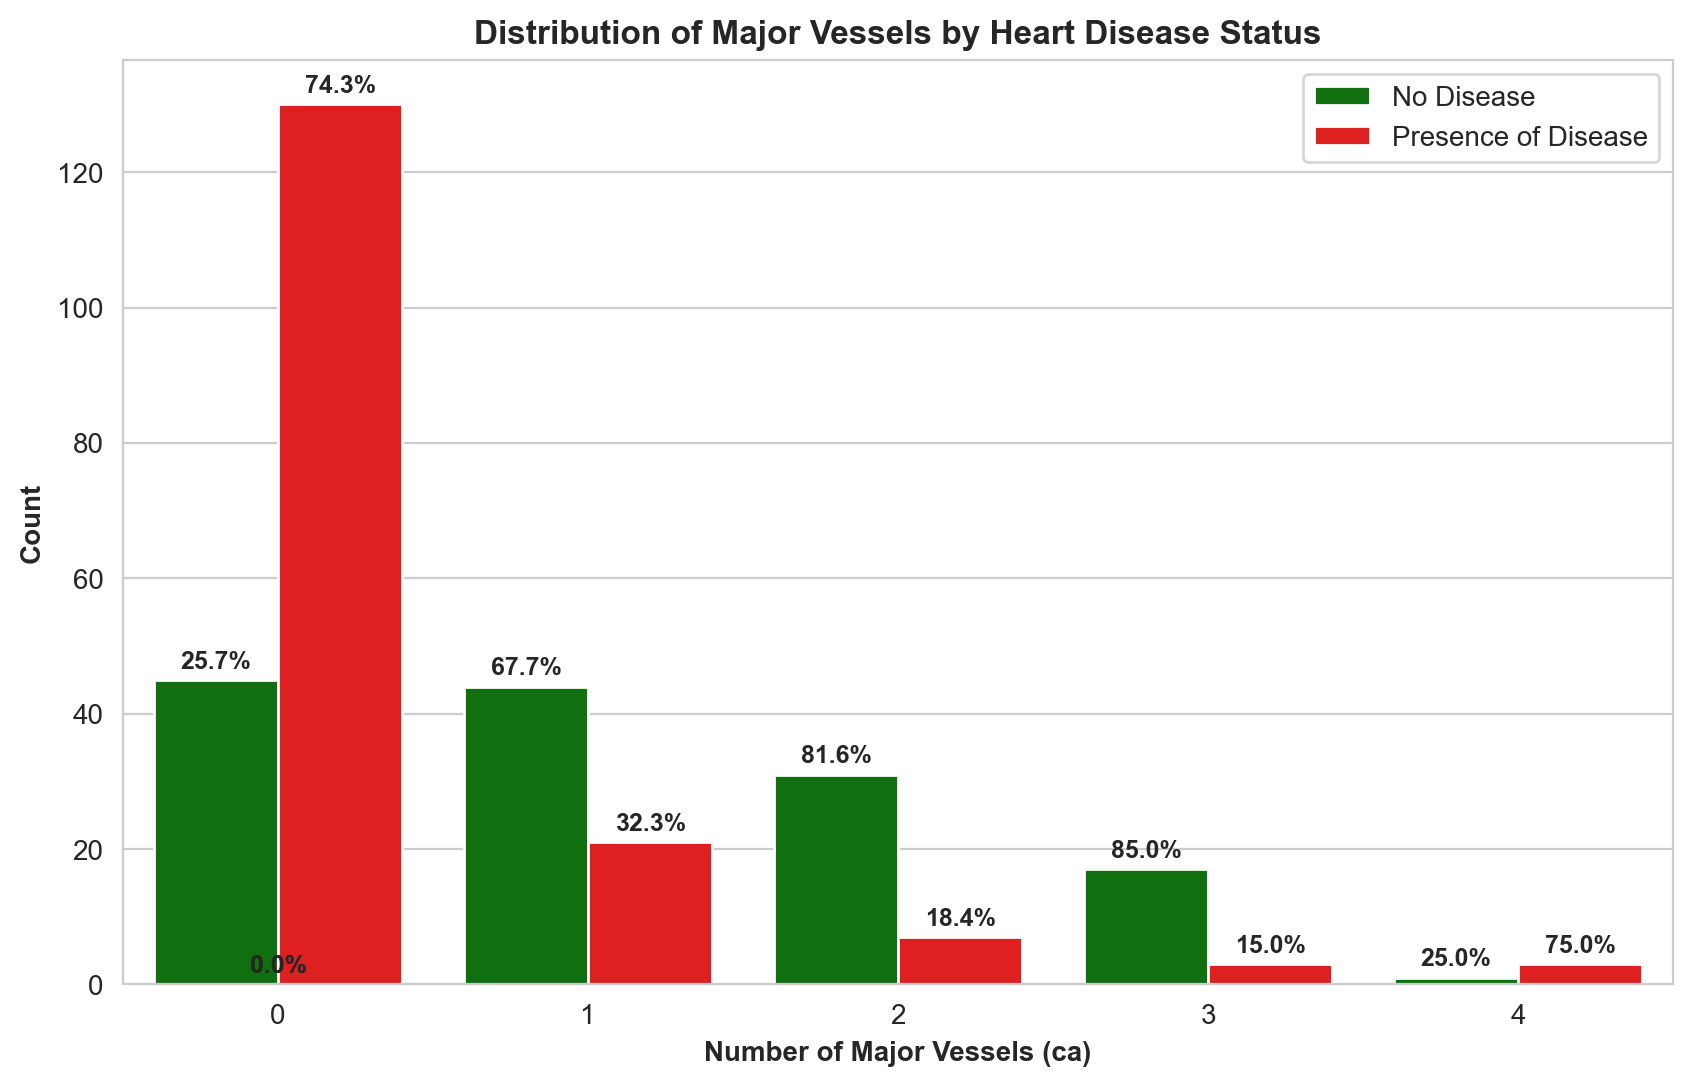

In [29]:
# Distribution of Major Vessels by Heart Disease Status

plt.figure(figsize=(10,6), dpi=200)
ax = sns.countplot(x='ca', hue='target', data=df1, palette={0:'green', 1:'red'})

#Add_percentage_on_bar
total_counts = df1['ca'].value_counts().to_dict()

for p in ax.patches:
    count = p.get_height()
    ca_value = p.get_x() + p.get_width() / 2
    total = total_counts.get(int(p.get_x() + p.get_width()/2 + 0.5), count)
    percent = 100 * count / total if total != 0 else 0
    ax.text(p.get_x() + p.get_width()/2, count + 1, f'{percent:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xlabel('Number of Major Vessels (ca)', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.title('Distribution of Major Vessels by Heart Disease Status', fontweight='bold')
plt.legend(['No Disease', 'Presence of Disease'])

plt.show()

The distribution of the number of major vessels observed through fluoroscopy is compared between participants with and without heart disease.
Higher values of `ca` appear more frequently among participants with heart disease in this dataset, suggesting an association between this feature and heart disease status.

### Correlation Between Continuous Variables

#### Heatmap

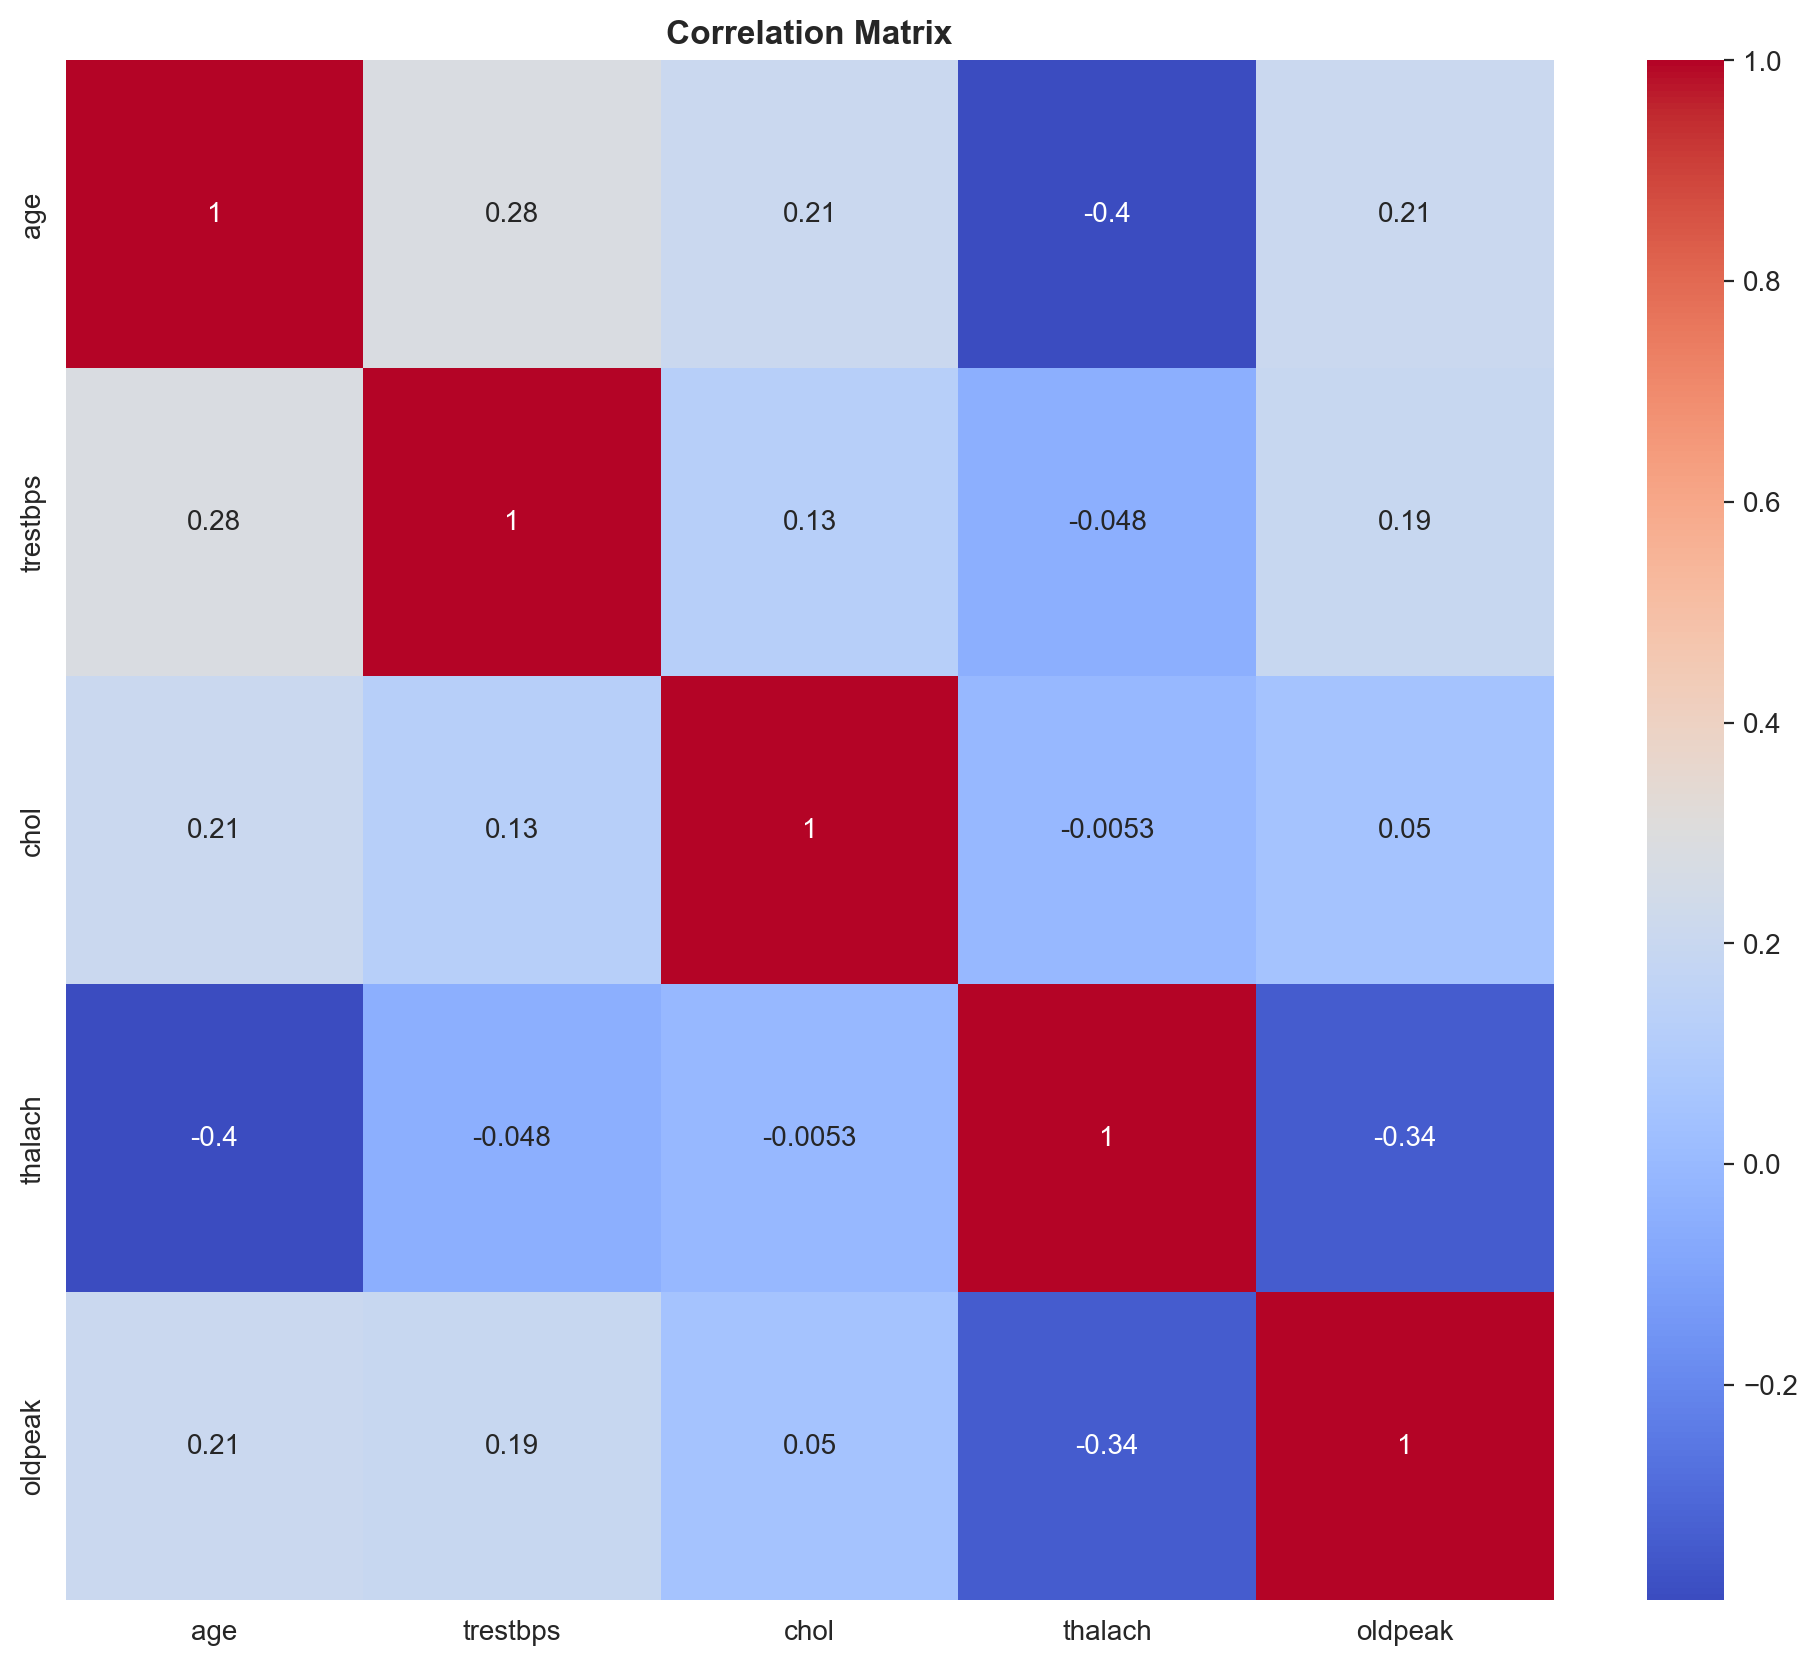

In [30]:
# Correlation of Continuous Features

plt.figure(figsize=(12,10), dpi=200)
corr = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']].corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix', fontweight='bold')
plt.show()


- Pearson correlation was used to examine the linear relationships between the continuous variables.


- The strongest observed relationship is the negative association between `age` and maximum heart rate (`thalach`). As age increases, maximum heart rate tends to decrease in this sample.


- A negative relationship is also observed between `thalach` and `oldpeak`, indicating that higher maximum heart rate tends to be associated with lower ST depression in the dataset.


- Correlation measures association between variables and does not imply causation.

## Conclusion


This exploratory analysis examined the structure, quality, distributions, and relationships within the Heart Disease dataset.

The dataset contained 303 observations initially, with one duplicate record identified and removed before the main analysis. No missing values were found, and the remaining data was examined for unusual values and potential outliers.

Several patterns were observed during the analysis. The distribution of heart disease differed between male and female participants, while the age distributions of participants with and without heart disease showed substantial overlap. Differences were also observed in the distribution of chest pain types, thalium stress test results, and the number of major vessels across the two heart disease groups.

Among the continuous variables, age and maximum heart rate showed a noticeable negative correlation. A potential outlier was also identified in the cholesterol variable, although it was retained because its value alone was not sufficient evidence that it was an erroneous observation.

Overall, the analysis reveals several associations between clinical features and heart disease status within this dataset. However, these findings describe patterns in the observed sample and should not be interpreted as causal relationships or as representative of the general population.

Further analysis could investigate these relationships using statistical testing and predictive modeling.

